# Desafio

A empresa Você Mais Seguro fornece planos de saúde e seguros de vida. 
A empresa está interessada em lança um novo seguro de veiculos, e desja entender a propensão de compra de seus clientes para este novo cenário. 
Em uma primeira etapa, foi realizada uma grande pesquisa com seus cleintes, para entender quais destes clientes estariam interessados em adquirir o novo seguro de veiculos.

Agora, com novos clientes do plano de saude entrando para sua base, a empresa deseja entender quais destes novos clientes teriam maior propensão de compra do novo seguro de veiculos.
No entanto, a empresa não esta interessada em gastar com pesquisas para todos os novos clientes, e sim apenas para aqueles que tem maior propensão de compra, 
haja visto,que seu efetivo comercial, não é capaz de entrar em contato, para fornecer um processo de pré vendas personalizado para toda a base de seus novos clientes, somente
para 2000 deles de cada vez. 

Para isso, este projeto tem como objetivo apresentar uma lista, com os 2000 clientes com maior probabilidade de venda do seguro de veículos.

# 0.0 Imports

In [1]:
import os
import json
import sys 

sys.path.append('../src')
import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np 
import seaborn as sns
import random as rd

from sklearn.linear_model   import LogisticRegression
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.tree           import DecisionTreeClassifier 
from sklearn.svm            import SVC 
from sklearn.ensemble       import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from xgboost                import XGBClassifier 
from sklearn import metrics as mt 

import data_utils as du 
import sys 

from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

from torch import nn 
import torch.nn.functional as F
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm 
import joblib


### 0.1 Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 8]
    plt.rcParams['font.size'] = 24
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    sns.set()

jupyter_settings()

def print_descriptive_stats(df,
                            column):
    print(f'**Clientes que adquiririam o Seguro - {column} statistics**')
    print(df[df.Response == 1][column].describe())
    print('-'*45)
    print(f'**Clientes NAO que adquiririam o Seguro - {column} statistics**')
    print(df[df.Response == 0][column].describe())
    print('\n')

def get_frequency_table(df, column): 

    df_frequency_1 = df[df.Response == 1].groupby(column).Response.count().reset_index()
    df_frequency_1.rename(columns={'Response':'Count_Response_1'}, inplace=True)


    df_frequency_0 = df[df.Response == 0].groupby(column).Response.count().reset_index()
    df_frequency_0.rename(columns={'Response':'Count_Response_0'}, inplace=True)

    df_frequency = pd.merge(df_frequency_1, df_frequency_0, on=column, how='inner') 
    df_frequency['Total'] = df_frequency['Count_Response_1'] + df_frequency['Count_Response_0']
    df_frequency['Propensity_to_buy'] = df_frequency['Count_Response_1']/df_frequency['Total']
    df_frequency['%_sample_to_buy'] = df_frequency['Count_Response_1']/df_frequency['Count_Response_1'].sum() 
    df_frequency['%_sample_to_not_buy'] = df_frequency['Count_Response_0']/df_frequency['Count_Response_0'].sum() 
    df_frequency['%_sample_size']   = df_frequency['Total']/len(df)
    df_frequency['%_general_propensity_to_buy'] = len(df[df.Response==1])/len(df)
    
    return df_frequency

def transform_pipeline(df):

    '''
    [EM FASE DE VALIDACAO....]
    '''
    from sklearn.preprocessing import StandardScaler, MinMaxScaler 


    region_code = df.Region_Code.copy()
    dummies_region_code = pd.get_dummies(region_code,prefix = "region_code")

    sales_channel = df.Policy_Sales_Channel.copy()
    dummies_sales_channel = pd.get_dummies(sales_channel,prefix = "policy_sales_channel")

    df_copy = df.copy()
    df_encoded = pd.concat([df_copy, dummies_sales_channel, dummies_region_code], axis = 1)

    df_encoded.loc[:,'Vehicle_Age'] = df_encoded.loc[:,'Vehicle_Age'].map({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2})


    df_encoded.drop(columns = ['Region_Code','Policy_Sales_Channel'], inplace = True)

    map_sexo_feminino = {
        'Male' : 0,
        'Female' : 1 
    }

    df_encoded['sexo_feminino'] = df_encoded.Gender.map(map_sexo_feminino)


    df_encoded.Vehicle_Damage = df_encoded.Vehicle_Damage.map({
        'Yes' : 1,
        'No'  : 0
    })


    scaller_premium      = MinMaxScaler()
    scaller_vintage      = MinMaxScaler()
    scaller_age          = MinMaxScaler()
    scaller_faixa_etaria = MinMaxScaler()

    df_encoded.Vintage_Scalled        = scaller_vintage.fit_transform(df_encoded.Vintage.values.reshape(-1,1))
    df_encoded.Annual_Premium_Scalled = scaller_premium.fit_transform(df_encoded.Annual_Premium.values.reshape(-1,1))


    df_encoded.Age        = scaller_age.fit_transform(df_encoded.Age.values.reshape(-1,1))
    df_encoded.faixa_etaria        = scaller_faixa_etaria.fit_transform(df_encoded.faixa_etaria.values.reshape(-1,1))


    df_encoded.Annual_Premium.describe()

    df_to_model = df_encoded[[x for x in df_encoded.columns if x not in ['id','Vintage_months','Vintage_weeks','Vintage']]]

    return df_to_model


def precision_top_k(top_k : int, 
                    y_true : np.array, 
                    y_proba : np.array):
    '''
    args:
        top_k: top_k elements to compute precision score
        y_true: true lables of y set 
        y_proba: estimated probabilities for y taking from some model 

    returns:
        precision : float - precision score. 
    '''
    evaluations = pd.DataFrame(y_true, 
                               columns = ['y_true'])
    evaluations['y_proba'] = y_proba
  
    evaluations = evaluations.sort_values(by = 'y_proba', ascending=False).reset_index(drop = True)
    evaluations = evaluations.iloc[:top_k]
    
    precision = evaluations.y_true.sum()/len(evaluations)

    return precision 

def recall_top_k(
        top_k : float,
        y_true : np.array, 
        y_proba : np.array
):
    
    evaluations = pd.DataFrame(y_true, 
                               columns = ['y_true'])
    evaluations['y_proba'] = y_proba
    evaluations = evaluations.sort_values(by = 'y_proba', ascending=False).reset_index(drop = True)
    
    
    recall = evaluations.iloc[:top_k].y_true.sum()/evaluations.y_true.sum()

    return recall 


def get_dataset_coverage(up_to : float = 0.8,
                         y_proba : np.array = None,
                         y_test : np.array = None):
    '''
    args:
        up_to: float - coverage up to value (between 0 and 1)
    returns:
        dataset_coverage: float - dataset coverage value necessary for reach the "up_to" recall value.
    '''

    df_coverage = pd.DataFrame({'y_true': y_test,
                                'y_proba': y_proba})
    df_coverage = df_coverage.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    df_coverage['cumulative_positives'] = df_coverage.y_true.cumsum()
    total_positives = df_coverage.y_true.sum()
    df_coverage['cumulative_positives_ratio'] = df_coverage['cumulative_positives']/total_positives

    dataset_coverage = df_coverage[df_coverage.cumulative_positives_ratio <= up_to].shape[0]/len(y_test)

    return dataset_coverage

def get_customers_contacted_up_to_revenue(up_to : float = 1e6,
                                            y_proba : np.array = None,
                                            y_test : np.array = None,
                                            revenue_per_customer : float = 554):
    '''
    args:
        up_to: float - target value revenue to be achieved
    returns:
        0 - if the model is not able to achieve the "up_to" revenue value with the whole dataset.
        dataset_coverage: float - customers value necessary to be abordated for reach the "up_to" revenue value.
    '''

    df_coverage = pd.DataFrame({'y_true': y_test,
                                'y_proba': y_proba})
    
    df_coverage = df_coverage.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    df_coverage['cumulative_revenue'] = df_coverage.y_true.cumsum() * revenue_per_customer
    
    if df_coverage.cumulative_revenue.max() < up_to:
        return 0 
    
    else: 
        dataset_coverage = df_coverage[df_coverage.cumulative_revenue <= up_to].shape[0]

    return dataset_coverage

def plot_precision_top_k(y_proba, y_true, label : str, line_style='-', chart_points = 100):
    precisions = []
    percentis = [x for x in range(1,chart_points,10)]
    for i in percentis:
        precisions.append(precision_top_k(
            top_k = int((i/chart_points)*len(y_proba)),
            y_true = y_true, 
            y_proba = y_proba
        ))
    
    df_results = pd.DataFrame(percentis, columns=['% Base'])
    df_results['Precision'] = precisions
    sns.lineplot(data = df_results,  x = '% Base', y = 'Precision', 
                 label=label, linestyle=line_style)
    plt.title('Precision vs % Base',fontdict={'fontsize': 24})

    return percentis, precisions 

def plot_recall_top_k(y_proba, 
                      y_true, 
                      label,
                      line_style='-'):
    
    recalls = []
    percentis = [x for x in range(1,100,10)]
    for i in percentis:
        recalls.append(recall_top_k(
                        top_k = int((i/100)*len(y_proba)),
                        y_true = y_true, 
                        y_proba = y_proba
                    ))
    
    df_results = pd.DataFrame(percentis, columns=['% Base'])
    df_results['Recall'] = recalls
    sns.lineplot(data = df_results,  x = '% Base', y = 'Recall', 
                 label=label, linestyle=line_style)
    
    plt.title('Recall vs % Base',
              fontdict={'fontsize': 24})
    
    return percentis, recalls 


def get_top_k_metrics(df_metrics,
                      y_proba : np.array,
                      y_test : pd.Series,
                      set_of_data : str = '' ):
        

        df_metrics[f'dataset_abrangence_r80{set_of_data}']    = get_dataset_coverage(
                                                    up_to=0.8,
                                                    y_proba=y_proba,
                                                    y_test=y_test.values
                                                )
        
        df_metrics[f'dataset_abrangence_r100{set_of_data}']    = get_dataset_coverage(
                                                    up_to=1.0,
                                                    y_proba=y_proba,
                                                    y_test=y_test.values
                                                )
        df_metrics[f'precision_top_10{set_of_data}']          = precision_top_k(top_k=10, y_true=y_test.values, y_proba=y_proba)
        df_metrics[f'precision_top_100{set_of_data}']         = precision_top_k(top_k=100, y_true=y_test.values, y_proba=y_proba)
        df_metrics[f'precision_top_1000{set_of_data}']        = precision_top_k(top_k=1000, y_true=y_test.values, y_proba=y_proba)
        df_metrics[f'precision_top_20000{set_of_data}']       = precision_top_k(top_k=20000, y_true=y_test.values, y_proba=y_proba)

        return df_metrics



def save_mapping_scaller(mapping : dict, 
                 save_path : str):
    
    with open(save_path, 'w') as f:
        json.dump(mapping, f)


#df_to_model = transform_pipeline(df_raw)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# 1.0 Limpeza dos Dados

**Tipos de limpezas**

* Nulos
* Tipagem inconsistente 
* Claros outliers (indicio de erro de digitação)


### 1.1 - Conhecendo o Dataset

In [3]:
df_raw = pd.read_csv('../data/raw/data.csv')
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# 3.0 - Preparação dos dados

In [4]:
df_3 = df_raw.copy()
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


**Split**

In [5]:
df_train, df_test = train_test_split(df_3, test_size=0.35, 
                                    random_state=43, 
                                     stratify=df_3.Response)

df_test, df_valid = train_test_split(
                                    df_test, test_size=0.5, 
                                    random_state=43, 
                                    stratify=df_test.Response)                      

print(f'''
      Train: {df_train.shape},
      Test: {df_test.shape},
      Valid: {df_valid.shape}''')


      Train: (247720, 12),
      Test: (66694, 12),
      Valid: (66695, 12)


### 3.1 - Criação de features

* Faixa etaria
* Tem entre 30 - 50 anos (EDA)
* Annual_Premium_br

In [6]:
df_train['faixa_etaria'] = df_train.Age.apply(lambda x: 10*(x//10))
df_train['entre_30_50'] = df_train.Age.apply(lambda x: 1 if (x>=30) and (x<=50) else 0)
df_train['Annual_Premium_br'] = df_train.Annual_Premium.apply(lambda x: x * 0.057)

df_test['faixa_etaria'] = df_test.Age.apply(lambda x: 10*(x//10))
df_test['entre_30_50'] = df_test.Age.apply(lambda x: 1 if (x>=30) and (x<=50) else 0)
df_test['Annual_Premium_br'] = df_test.Annual_Premium.apply(lambda x: x * 0.057)


df_valid['faixa_etaria'] = df_valid.Age.apply(lambda x: 10*(x//10))
df_valid['entre_30_50'] = df_valid.Age.apply(lambda x: 1 if (x>=30) and (x<=50) else 0)
df_valid['Annual_Premium_br'] = df_valid.Annual_Premium.apply(lambda x: x * 0.057)



### 3.1 - Encodings

* Adicionar label encodings e frequency encoding.

#### 3.1.1 - Label Encoder

* Policy Sales Channel 
* Region Code

**Region Code**

A justificativa se da pela ausencia de elação quantitativa nos dados de region code. 

A regiao "102" ser maior que a regiao "32" não faz sentido


In [25]:
def get_frequency_encoder(df, 
                          column_name,
                          target_column = 'Response',
                          save_mapping_path : str = None):
    
    df_frequency = df.groupby(column_name)[target_column].mean().reset_index()
    map_frequency = dict(zip(df_frequency[column_name], df_frequency[target_column]))
    
    frenquency_encoded = df[column_name].map(map_frequency)
    
    if save_mapping_path:
        with open(save_mapping_path, 'w') as f:
            json.dump(map_frequency, f)
    
    return frenquency_encoded, map_frequency



In [26]:
region_code_encoded, map_region_code = get_frequency_encoder(df_train, 
                                                  column_name='Region_Code', 
                                                  target_column='Response')


df_train['Region_Code_encoded'] = df_train.Region_Code.map(map_region_code)
# Por ser frequency encoder, items nao presentes no teste (frequencia muito baixa) serao mapeados para 0 (zero).
df_test['Region_Code_encoded']  = df_test.Region_Code.map(map_region_code)
df_test['Region_Code_encoded'].fillna(0, inplace=True)

df_valid['Region_Code_encoded'] = df_valid.Region_Code.map(map_region_code)
df_valid['Region_Code_encoded'].fillna(0, inplace=True)

save_mapping_scaller(mapping=map_region_code,
                     save_path = '../models/encoders/mappings/region_code.json') 

df_train.Region_Code_encoded.value_counts()

Region_Code_encoded
0.187002    69165
0.095723    22095
0.101905    12914
0.121994    11894
0.073086     8620
0.075576     7939
0.127055     7178
0.062120     6584
0.125457     6018
0.110925     5968
0.079873     5659
0.096736     5086
0.086469     4811
0.124453     4572
0.068104     4082
0.113536     3620
0.079418     3576
0.131380     3311
0.103211     3052
0.127646     3024
0.092008     2978
0.061988     2807
0.072049     2762
0.091388     2659
0.069296     2612
0.132173     2126
0.099806     2064
0.085191     2019
0.079339     1815
0.084491     1799
0.085344     1699
0.075045     1679
0.043295     1663
0.071820     1643
0.143766     1572
0.085779     1329
0.183873     1327
0.063359     1310
0.110163     1289
0.148638     1285
0.105600     1250
0.076078     1183
0.139616     1146
0.077135     1089
0.171906     1018
0.065611      884
0.113341      847
0.115479      814
0.110092      654
0.037523      533
0.069652      402
0.142857      168
0.149606      127
Name: count, dtype: int64

**Policy Sales Channel**

In [27]:
#sales_channel = df_3.Policy_Sales_Channel.copy()
#dummies_sales_channel = pd.get_dummies(sales_channel,prefix = "policy_sales_channel")
#dummies_sales_channel.info()

In [28]:
policy_sales_channel_encoded, map_policy_sales_channel = get_frequency_encoder(df_train, 
                                                  column_name='Policy_Sales_Channel', 
                                                  target_column='Response')

df_train['Policy_Sales_Channel_encoded'] = df_train.Policy_Sales_Channel.map(map_policy_sales_channel)
df_test['Policy_Sales_Channel_encoded']  = df_test.Policy_Sales_Channel.map(map_policy_sales_channel)
df_test.Policy_Sales_Channel_encoded.fillna(0, inplace=True)

df_valid['Policy_Sales_Channel_encoded'] = df_valid.Policy_Sales_Channel.map(map_policy_sales_channel)
df_valid.Policy_Sales_Channel_encoded.fillna(0, inplace=True)

save_mapping_scaller(mapping=map_policy_sales_channel,
                     save_path = '../models/encoders/mappings/policy_sales_channel.json')

df_train.Policy_Sales_Channel_encoded.value_counts()


Policy_Sales_Channel_encoded
0.028680    87623
0.199061    51773
0.190271    48184
0.021667    14169
0.211658     6931
0.169817     6401
0.268208     4325
0.241476     3930
0.030075     2527
0.310178     1857
0.206531     1225
0.145349     1204
0.109628     1049
0.087310      985
0.107744      891
0.156584      843
0.340025      797
0.094458      794
0.033141      694
0.096870      671
0.120244      657
0.077601      567
0.118919      555
0.164706      510
0.083168      505
0.129555      494
0.241050      419
0.106329      395
0.058824      391
0.101299      385
0.084795      342
0.299120      341
0.105740      331
0.208589      326
0.263666      311
0.125954      262
0.048077      208
0.000000      206
0.254902      204
0.166667      198
0.200000      175
0.089041      146
0.259542      131
0.181102      127
0.130435      115
0.131579      114
0.137615      109
0.046296      108
0.102804      107
0.051546       97
0.095745       94
0.118280       93
0.129032       93
0.215054       93

****

**Region Code**

#### 3.1.2 - Binary Encoding

* Gender
* Driving License
* Previously Insured
* Vehicle Damage
* Response

In [29]:
map_sexo_feminino = {
    'Male' : 0,
    'Female' : 1 
}

df_train['sexo_feminino'] = df_train.Gender.map(map_sexo_feminino)
df_test['sexo_feminino']  = df_test.Gender.map(map_sexo_feminino)
df_valid['sexo_feminino'] = df_valid.Gender.map(map_sexo_feminino)    

save_mapping_scaller(mapping=map_sexo_feminino,
                     save_path = '../models/encoders/mappings/sexo_feminino.json')


**Checagem dos demais campos**

In [30]:
df_train.Driving_License.value_counts()

Driving_License
1    247164
0       556
Name: count, dtype: int64

In [31]:
df_train.Previously_Insured.value_counts()

Previously_Insured
0    134221
1    113499
Name: count, dtype: int64

In [32]:
df_train.Vehicle_Damage.value_counts()

Vehicle_Damage
Yes    125071
No     122649
Name: count, dtype: int64

In [33]:
map_vehicle_damage = {
    'Yes' : 1,
    'No'  : 0
}

df_train['Vehicle_Damage_encoded'] = df_train.Vehicle_Damage.map(map_vehicle_damage)
df_test['Vehicle_Damage_encoded']  = df_test.Vehicle_Damage.map(map_vehicle_damage)
df_valid['Vehicle_Damage_encoded'] = df_valid.Vehicle_Damage.map(map_vehicle_damage)

save_mapping_scaller(mapping=map_vehicle_damage,
                     save_path = '../models/encoders/mappings/vehicle_damage.json')

df_train.Vehicle_Damage.value_counts()


Vehicle_Damage
Yes    125071
No     122649
Name: count, dtype: int64

### 3.1.3 - Ordinal Encoding

In [16]:
map_vehicle_age = {
    '< 1 Year' : 0,
    '1-2 Year' : 1,
    '> 2 Years' : 2
}

df_train.loc[:,'Vehicle_Age'] = df_train.loc[:,'Vehicle_Age'].map(map_vehicle_age)
df_test.loc[:,'Vehicle_Age']  = df_test.loc[:,'Vehicle_Age'].map(map_vehicle_age)
df_valid.loc[:,'Vehicle_Age'] = df_valid.loc[:,'Vehicle_Age'].map(map_vehicle_age)

save_mapping_scaller(mapping=map_vehicle_age,
                     save_path = '../models/encoders/mappings/vehicle_age.json')


### 3.2 - Variaveis Numéricas (Padronização,  Normalização, transformação ciclica, etc.)

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler 


scaller_premium      = MinMaxScaler()
scaller_vintage      = MinMaxScaler()
scaller_age          = MinMaxScaler()
scaller_faixa_etaria = MinMaxScaler()

df_train['vintage_encoded']        = scaller_vintage.fit_transform(df_train.Vintage.values.reshape(-1,1))
df_test['vintage_encoded']         = scaller_vintage.transform(df_test.Vintage.values.reshape(-1,1))
df_valid['vintage_encoded']        = scaller_vintage.transform(df_valid.Vintage.values.reshape(-1,1))
joblib.dump(scaller_vintage, '../models/encoders/scallers/vintage_scaler.pkl')


df_train['annual_premium_encoded'] = scaller_premium.fit_transform(df_train.Annual_Premium.values.reshape(-1,1))
df_test['annual_premium_encoded']  = scaller_premium.transform(df_test.Annual_Premium.values.reshape(-1,1))
df_valid['annual_premium_encoded'] = scaller_premium.transform(df_valid.Annual_Premium.values.reshape(-1,1))
joblib.dump(scaller_premium, '../models/encoders/scallers/annual_premium_scaler.pkl')


df_train['age_encoded']                 = scaller_age.fit_transform(df_train.Age.values.reshape(-1,1))
df_test['age_encoded']                  = scaller_age.transform(df_test.Age.values.reshape(-1,1))
df_valid['age_encoded']                 = scaller_age.transform(df_valid.Age.values.reshape(-1,1))
joblib.dump(scaller_age, '../models/encoders/scallers/age_scaler.pkl')

df_train['faixa_etaria_encoded']        = scaller_faixa_etaria.fit_transform(df_train.faixa_etaria.values.reshape(-1,1))
df_test['faixa_etaria_encoded']         = scaller_faixa_etaria.transform(df_test.faixa_etaria.values.reshape(-1,1))
df_valid['faixa_etaria_encoded']        = scaller_faixa_etaria.transform(df_valid.faixa_etaria.values.reshape(-1,1))
joblib.dump(scaller_faixa_etaria, '../models/encoders/scallers/faixa_etaria_scaler.pkl')    

df_train.Annual_Premium.describe()

count    247720.000000
mean      30575.039545
std       17290.965996
min        2630.000000
25%       24392.000000
50%       31666.000000
75%       39393.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

**Ajuste de tipagem**

In [18]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247720 entries, 223039 to 14188
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            247720 non-null  int64  
 1   Gender                        247720 non-null  object 
 2   Age                           247720 non-null  int64  
 3   Driving_License               247720 non-null  int64  
 4   Region_Code                   247720 non-null  float64
 5   Previously_Insured            247720 non-null  int64  
 6   Vehicle_Age                   247720 non-null  object 
 7   Vehicle_Damage                247720 non-null  object 
 8   Annual_Premium                247720 non-null  float64
 9   Policy_Sales_Channel          247720 non-null  float64
 10  Vintage                       247720 non-null  int64  
 11  Response                      247720 non-null  int64  
 12  faixa_etaria                  247720 non-null

In [19]:
df_train['Vehicle_Age'] = df_train['Vehicle_Age'].astype('float32') 
df_test['Vehicle_Age'] = df_test['Vehicle_Age'].astype('float32') 
df_valid['Vehicle_Age'] = df_valid['Vehicle_Age'].astype('float32') 
    
df_train['Vehicle_Age'] = df_train['Vehicle_Age'].astype('int64') 
df_train['Vehicle_Age'] = df_train['Vehicle_Age'].astype('int64') 
df_train['Vehicle_Age'] = df_train['Vehicle_Age'].astype('int64') 


### 3.3 - Feature Selection

In [20]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247720 entries, 223039 to 14188
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            247720 non-null  int64  
 1   Gender                        247720 non-null  object 
 2   Age                           247720 non-null  int64  
 3   Driving_License               247720 non-null  int64  
 4   Region_Code                   247720 non-null  float64
 5   Previously_Insured            247720 non-null  int64  
 6   Vehicle_Age                   247720 non-null  int64  
 7   Vehicle_Damage                247720 non-null  object 
 8   Annual_Premium                247720 non-null  float64
 9   Policy_Sales_Channel          247720 non-null  float64
 10  Vintage                       247720 non-null  int64  
 11  Response                      247720 non-null  int64  
 12  faixa_etaria                  247720 non-null

In [21]:
inference_cols_fs = [x for x in df_train.columns if x.lower() not in ['age','vintage','annual_premium','faixa_etaria','response','gender','id',
                                                                   'policy_sales_channel', 'vehicle_damage', 'vehicle_age',
                                                                'annual_premium_br', 'region_code']]                                                               

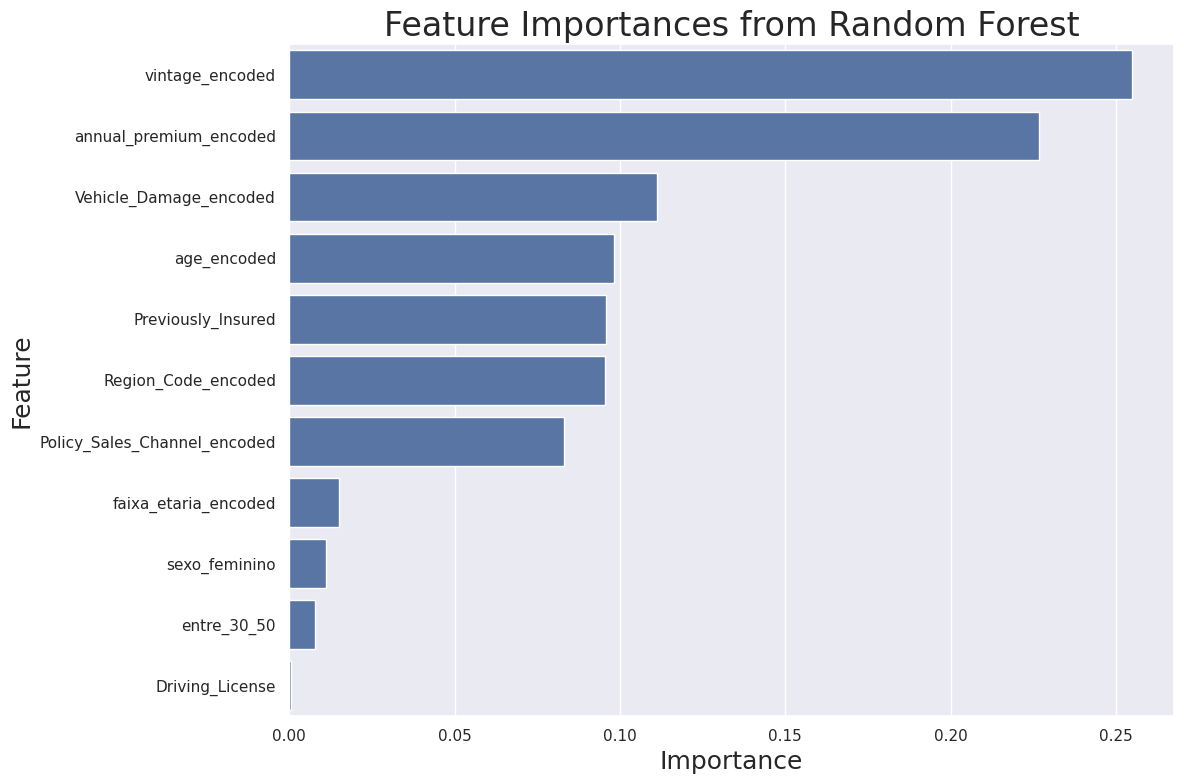

In [22]:
random_forest_feature_selection = RandomForestClassifier(n_estimators=50, 
                                                         random_state=42,
                                                         criterion='entropy') 

random_forest_feature_selection.fit(df_train[inference_cols_fs], df_train.Response)
random_forest_importances = random_forest_feature_selection.feature_importances_
feature_importances_df = pd.DataFrame({'Feature': inference_cols_fs, 'Importance': random_forest_importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
plt.title('Feature Importances from Random Forest', fontdict={'fontsize': 24})
plt.xlabel('Importance', fontdict={'fontsize': 18})
plt.ylabel('Feature', fontdict={'fontsize': 18})
plt.tight_layout()

In [23]:
inference_cols = [x for x in df_train.columns if x.lower() not in ['age','vintage','annual_premium','faixa_etaria','response','gender','id',
                                                                   'vintage_months','vintage_weeks',
                                                                'policy_sales_channel', 'vehicle_damage', 'vehicle_age',
                                                                'annual_premium_br', 'region_code', 
                                                                'Driving_License', 'entre_30_50', 'sexo_feminino', 'faixa_etaria_encoded']]
X_train = df_train[inference_cols]
y_train = df_train.Response

X_test = df_test[inference_cols]
y_test = df_test.Response

X_valid = df_valid[inference_cols]
y_valid = df_valid.Response

X = pd.concat([X_train, X_test, X_valid], axis = 0)
y = pd.concat([y_train, y_test, y_valid], axis = 0)

print(f'''
      Train: {X_train.shape},
      Test: {X_test.shape},
      Valid: {X_valid.shape}''')


      Train: (247720, 8),
      Test: (66694, 8),
      Valid: (66695, 8)


In [24]:
X_train.columns

Index(['Driving_License', 'Previously_Insured', 'Region_Code_encoded',
       'Policy_Sales_Channel_encoded', 'Vehicle_Damage_encoded',
       'vintage_encoded', 'annual_premium_encoded', 'age_encoded'],
      dtype='object')

# 4.0 - Data balancing 

#### 3.3.1 - RandomOverSampling

**Os modelos avaliados apresentaram melhora nos resultados de treinamento porém com dados de teste pouco houve alteração, indicando que a ação acabou gerando overfiting.**

In [34]:
from imblearn.over_sampling import RandomOverSampler 
ros = RandomOverSampler(random_state=42) 

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
X_train_ros.shape


(434718, 8)

In [35]:
y_train_ros.value_counts()

Response
0    217359
1    217359
Name: count, dtype: int64

In [36]:
rf = RandomForestClassifier(criterion='entropy',
                            n_estimators=20,
                            max_depth=30,
                            n_jobs=-1)
rf.fit(X = X_train_ros,
          y = y_train_ros)


RandomForestClassifier(criterion='entropy', max_depth=30, n_estimators=20,
                       n_jobs=-1)

In [37]:
dt = DecisionTreeClassifier(criterion='entropy',
                            max_depth=30)
dt.fit(X = X_train_ros,
          y = y_train_ros)


DecisionTreeClassifier(criterion='entropy', max_depth=30)

In [38]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X = X_train_ros,
          y = y_train_ros) 

LogisticRegression()

In [39]:
metrics_dt = du.computeMetricsSklearnModel(model = dt,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_dt = pd.DataFrame(metrics_dt)
metrics_dt['model'] = 'Decision Tree'

In [40]:

metrics_rf = du.computeMetricsSklearnModel(model = rf,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'

In [41]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66694 entries, 267021 to 318435
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Driving_License               66694 non-null  int64  
 1   Previously_Insured            66694 non-null  int64  
 2   Region_Code_encoded           66694 non-null  float64
 3   Policy_Sales_Channel_encoded  66694 non-null  float64
 4   Vehicle_Damage_encoded        66694 non-null  int64  
 5   vintage_encoded               66694 non-null  float64
 6   annual_premium_encoded        66694 non-null  float64
 7   age_encoded                   66694 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 4.6 MB


In [42]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66694 entries, 267021 to 318435
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Driving_License               66694 non-null  int64  
 1   Previously_Insured            66694 non-null  int64  
 2   Region_Code_encoded           66694 non-null  float64
 3   Policy_Sales_Channel_encoded  66694 non-null  float64
 4   Vehicle_Damage_encoded        66694 non-null  int64  
 5   vintage_encoded               66694 non-null  float64
 6   annual_premium_encoded        66694 non-null  float64
 7   age_encoded                   66694 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 4.6 MB


In [43]:
for c in X_test.columns:
    print(f'{c} - {X_valid[c].isnull().sum()}')

Driving_License - 0
Previously_Insured - 0
Region_Code_encoded - 0
Policy_Sales_Channel_encoded - 0
Vehicle_Damage_encoded - 0
vintage_encoded - 0
annual_premium_encoded - 0
age_encoded - 0


In [44]:

metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))



metrics_lr = pd.DataFrame(metrics_lr)
metrics_lr['model'] = 'Logistic Regression'

In [45]:
metrics_random_over_sample = pd.concat([metrics_dt, metrics_rf, metrics_lr], axis=0)
metrics_random_over_sample.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.967855,0.939597,0.999995,0.968856,None,Random Forest
train,0.941091,0.900922,0.991185,0.943901,None,Decision Tree
train,0.788481,0.720824,0.941673,0.816580,None,Logistic Regression
valid,0.673649,0.265227,0.939083,0.413631,None,Logistic Regression
test,0.672849,0.264782,0.939564,0.413136,None,Logistic Regression
valid,0.812865,0.331243,0.516942,0.403764,None,Random Forest
test,0.809938,0.324798,0.510521,0.397013,None,Random Forest
valid,0.791574,0.301125,0.530275,0.384121,None,Decision Tree
test,0.792035,0.299972,0.522510,0.381135,None,Decision Tree


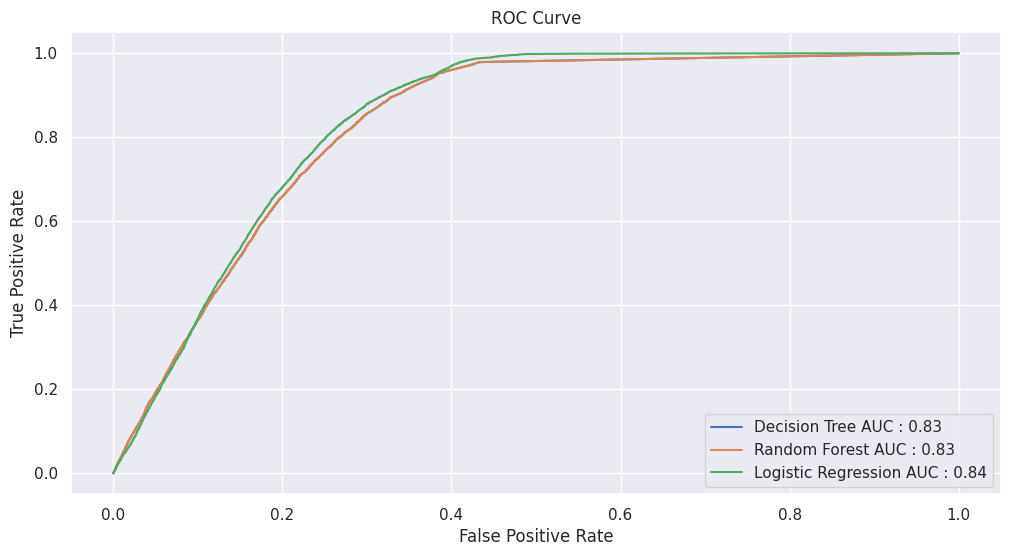

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

def plot_roc(ax,
        datase_train,
        dataset_test,
        model,
        title
):
    x_train, y_train = datase_train
    x_test,  y_test  = dataset_test

    y_test_prob = model.predict_proba(x_test)[:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_test_prob)

    auc = roc_auc_score(y_test, y_test_prob)
    ax.plot(fpr, tpr, label=f'{title} AUC : {auc:.2f}')

    ax.set_title('ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc=0)


def plot_precision_recall_curve(ax, 
                                dataset_train,
                                dataset_test,
                                model,
                                title : str):
    
    x_train, y_train = dataset_train
    x_test,  y_test  = dataset_test

    y_test_prob = model.predict_proba(x_test)[:,1]
    precision, recall, thresholds = precision_recall_curve(y_true = y_test,
    
                                                        probas_pred = y_test_prob)
    ax.plot(thresholds, precision[:-1], label=f'{title} - Precision')
    ax.plot(thresholds, recall[:-1], label=f'{title} - Recall')
    ax.set_title('Precision-Recall Curve')
    ax.set_xlabel('Thresholds')
    ax.set_ylabel('Precision/Recall')
    ax.legend(loc=0)

    return precision, recall, thresholds 


fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Decision Tree'
)

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = logistic_model,
    title = 'Logistic Regression'
)
    

(array([0.12255975, 0.23905965, 0.23906679, ..., 0.5       , 0.33333333,
        1.        ]),
 array([1.00000000e+00, 9.79080010e-01, 9.79080010e-01, ...,
        2.44678248e-04, 1.22339124e-04, 0.00000000e+00]),
 array([0.        , 0.00212766, 0.00217391, ..., 0.99642857, 0.9990566 ,
        1.        ]))

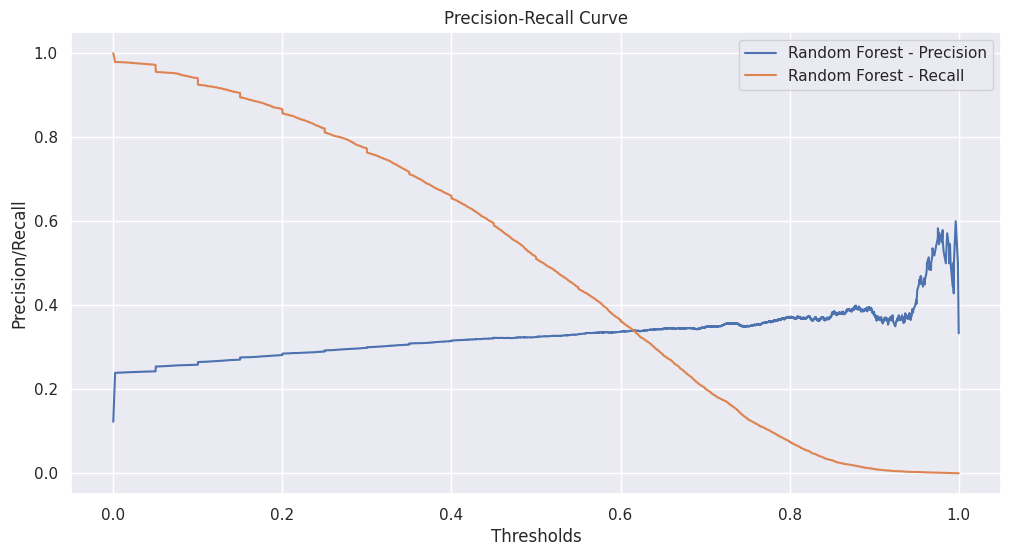

In [47]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)



(array([0.12255975, 0.12256159, 0.12256343, ..., 0.        , 0.        ,
        1.        ]),
 array([1., 1., 1., ..., 0., 0., 0.]),
 array([4.76531054e-04, 8.21326026e-04, 8.96749570e-04, ...,
        9.65411268e-01, 9.84633697e-01, 9.87342048e-01]))

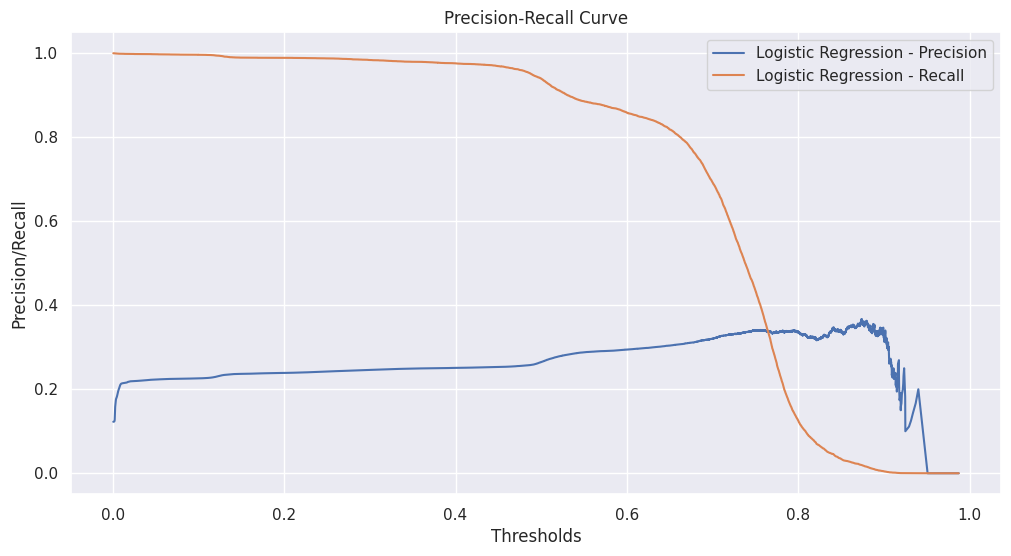

In [48]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = logistic_model,
    title = 'Logistic Regression'
)

**Overfitting com random over sample**

##### 3.3.1.2 - SMOTE

In [49]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()

Response
0    217359
1    217359
Name: count, dtype: int64

In [50]:
rf_normal = RandomForestClassifier(criterion='entropy',
                            n_estimators=26,
                            max_depth=32,
                            n_jobs=-1)
rf_normal.fit(X = X_train,
          y = y_train)

RandomForestClassifier(criterion='entropy', max_depth=32, n_estimators=26,
                       n_jobs=-1)

In [51]:
rf = RandomForestClassifier(criterion='entropy',
                            n_estimators=26,
                            max_depth=16,
                            n_jobs=-1)
rf.fit(X = X_train_smote,
          y = y_train_smote)


RandomForestClassifier(criterion='entropy', max_depth=16, n_estimators=26,
                       n_jobs=-1)

In [52]:
metrics_rf = du.computeMetricsSklearnModel(model = rf_normal,
                              dataset_train = (X_train, y_train),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'
metrics_rf

,accuracy,precision,recall,f1_score,auc,model
train,0.984527,0.998122,0.875399,0.932741,None,Random Forest
test,0.866390,0.357004,0.112552,0.171147,None,Random Forest
valid,0.868116,0.375050,0.114006,0.174859,None,Random Forest


In [53]:
metrics_rf = du.computeMetricsSklearnModel(model = rf,
                              dataset_train = (X_train_smote, y_train_smote),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'
metrics_rf

,accuracy,precision,recall,f1_score,auc,model
train,0.856728,0.793954,0.963503,0.870550,None,Random Forest
test,0.749798,0.304182,0.808906,0.442112,None,Random Forest
valid,0.749996,0.304558,0.810031,0.442677,None,Random Forest


(array([0.12255975, 0.1407567 , 0.14109719, ..., 0.        , 0.        ,
        1.        ]),
 array([1.        , 0.99902129, 0.99902129, ..., 0.        , 0.        ,
        0.        ]),
 array([0.00000000e+00, 7.88792831e-06, 8.79522947e-06, ...,
        8.66601476e-01, 8.72021725e-01, 9.34318580e-01]))

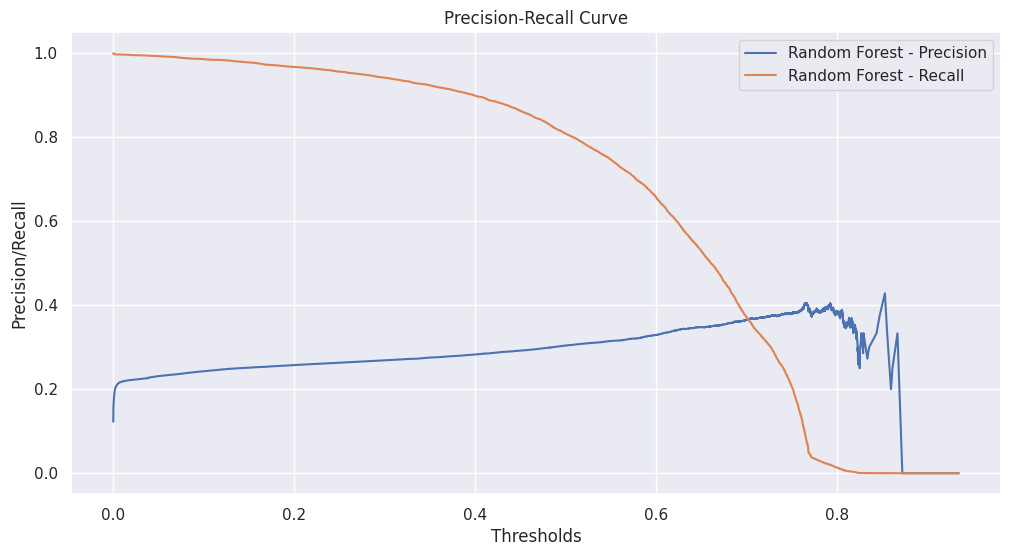

In [54]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_smote, y_train_smote),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)



#### 3.3.2 - UnderSampling

##### Random Under Sampling

**O Overfitting se mantem**

In [55]:
from imblearn.under_sampling import RandomUnderSampler
random_under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = random_under.fit_resample(X_train, y_train)
y_train_under.value_counts()

Response
0    30361
1    30361
Name: count, dtype: int64

In [56]:
def run_battery_test(
        curr_dataset_train,
        dataset_test,
        dataset_valid
):
        X_train, y_train = curr_dataset_train
        X_test,  y_test  = dataset_test
        X_valid, y_valid = dataset_valid

        rf_model = RandomForestClassifier(criterion='gini',
                                n_estimators=100,
                                max_depth=48,
                                n_jobs=-1,
                                class_weight='balanced',
                                max_features='log2',
                                bootstrap=True
                                ,max_samples=0.8
                                )
        rf_model.fit(X = X_train,
                y = y_train)

        dt_model = DecisionTreeClassifier(criterion='gini',
                                max_depth=16)
        dt_model.fit(X = X_train,
                y = y_train)

        logistic_model = LogisticRegression(class_weight='balanced')
        logistic_model.fit(X = X_train,
                y = y_train) 

        metrics_rf = du.computeMetricsSklearnModel(model = rf_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))


        metrics_rf = pd.DataFrame(metrics_rf)
        metrics_rf['model'] = 'Random Forest'

        metrics_dt = du.computeMetricsSklearnModel(model = dt_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_dt = pd.DataFrame(metrics_dt)
        metrics_dt['model'] = 'Decision Tree'

        metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_lr = pd.DataFrame(metrics_lr)
        metrics_lr['model'] = 'Logistic Regression'

        metrics_all = pd.concat([metrics_rf, metrics_dt, metrics_lr], axis=0)
        metrics_all.sort_values(by=['f1_score'], ascending=False)

        return rf_model, dt_model, logistic_model, metrics_all




In [57]:
rf_normal, dt_normal, lr_normal, metrics_normal = run_battery_test(
    curr_dataset_train = (X_train, y_train),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_normal.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.998252,0.998136,0.987583,0.992831,None,Random Forest
valid,0.674773,0.265786,0.938104,0.414216,None,Logistic Regression
train,0.673845,0.265467,0.940121,0.414024,None,Logistic Regression
test,0.674004,0.265357,0.938586,0.413741,None,Logistic Regression
train,0.888903,0.807626,0.122789,0.213169,None,Decision Tree
valid,0.869016,0.377671,0.105933,0.165457,None,Random Forest
test,0.868099,0.365326,0.103377,0.161152,None,Random Forest
valid,0.868656,0.273431,0.043180,0.074583,None,Decision Tree
test,0.869044,0.276358,0.042329,0.073414,None,Decision Tree


(array([0.12255975, 0.22754457, 0.23873807, ..., 0.5       , 1.        ,
        1.        ]),
 array([1.00000000e+00, 9.91436261e-01, 9.82260827e-01, ...,
        1.22339124e-04, 1.22339124e-04, 0.00000000e+00]),
 array([0.       , 0.01     , 0.0164155, ..., 0.91     , 0.92     ,
        0.93     ]))

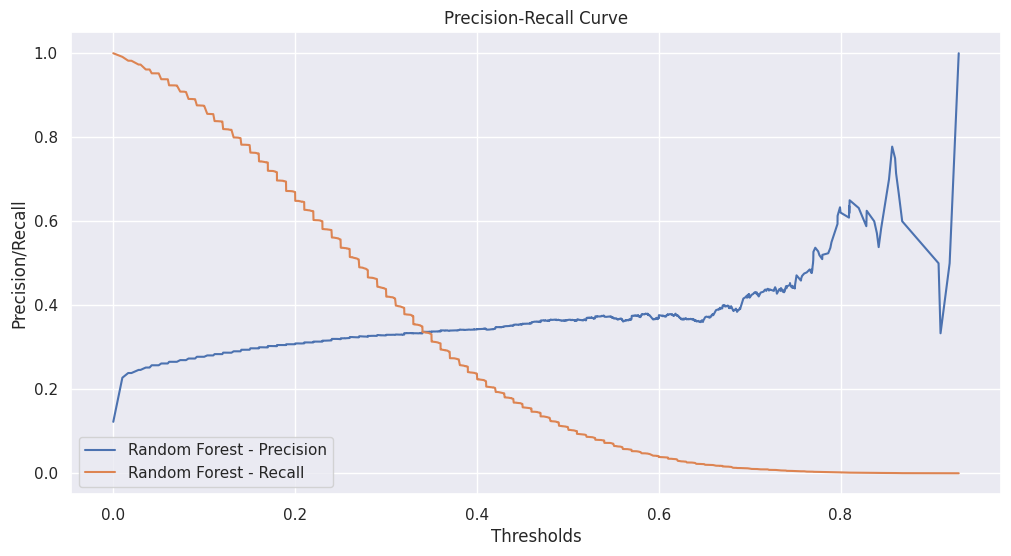

In [58]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train, y_train),
    dataset_test  = (X_test, y_test),
    model = rf_normal,
    title = 'Random Forest'
)



In [59]:
pd.DataFrame(zip([ x*-1 if x < 0 else x for x in lr_normal.coef_[0] ], X_train.columns), columns = ['feature_importance','feature_name']).sort_values(by='feature_importance', ascending=False)


,feature_importance,feature_name
3,7.137616,Policy_Sales_Channel_encoded
1,4.010067,Previously_Insured
2,3.287376,Region_Code_encoded
4,1.959145,Vehicle_Damage_encoded
6,1.250514,annual_premium_encoded
7,1.082113,age_encoded
0,1.059039,Driving_License
5,0.007619,vintage_encoded


In [60]:
pd.DataFrame(zip(rf_normal.feature_importances_, X_train.columns), columns = ['feature_importance','feature_name']).sort_values(by='feature_importance', ascending=False)

,feature_importance,feature_name
5,0.199733,vintage_encoded
4,0.184209,Vehicle_Damage_encoded
6,0.175948,annual_premium_encoded
1,0.146907,Previously_Insured
7,0.121966,age_encoded
3,0.096966,Policy_Sales_Channel_encoded
2,0.073472,Region_Code_encoded
0,0.000798,Driving_License


In [61]:
rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under, y_train_under),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.998880,0.998289,0.999473,0.998881,None,Random Forest
train,0.849807,0.789663,0.953625,0.863933,None,Decision Tree
train,0.789104,0.720745,0.943941,0.817381,None,Logistic Regression
valid,0.712347,0.283217,0.879755,0.428491,None,Random Forest
test,0.712193,0.281875,0.871177,0.425935,None,Random Forest
valid,0.698973,0.274001,0.882569,0.418176,None,Decision Tree
test,0.697364,0.272365,0.879007,0.415871,None,Decision Tree
valid,0.670920,0.264040,0.942630,0.412527,None,Logistic Regression
test,0.669625,0.263077,0.941400,0.411233,None,Logistic Regression


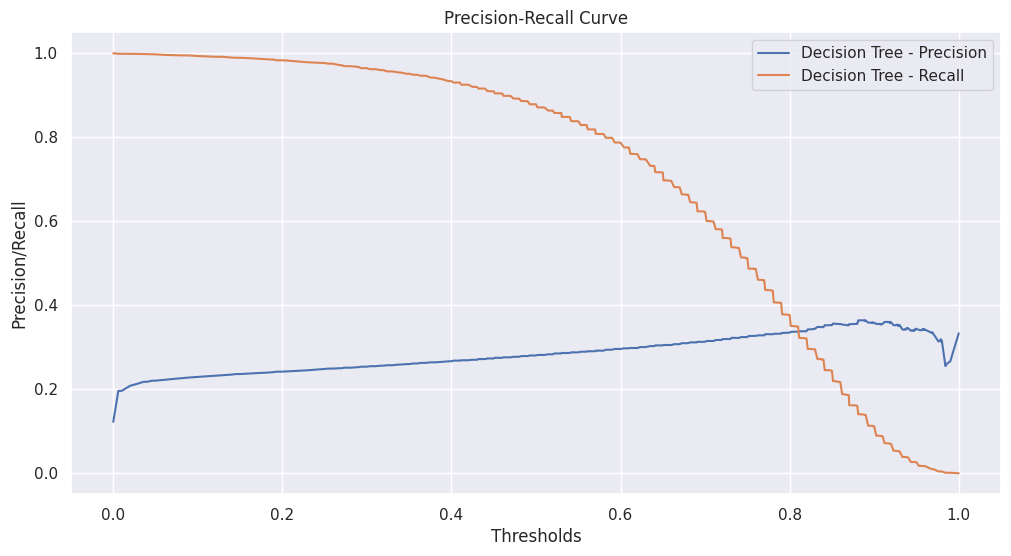

In [62]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

content = plot_precision_recall_curve(ax,
    dataset_train = (X_train_under, y_train_under),
    dataset_test  = (X_test, y_test),
    model = rf_under,
    title = 'Decision Tree'
)

**Teste reduzindo o numero de features**

In [63]:
importances = pd.DataFrame({'feature': X_train_under.columns, 'importance': lr_under.coef_[0]})
importances.importance = importances.importance.abs()
select_cols_lr = importances[importances.importance >= importances.importance.quantile(0.8)].feature.tolist()
len(select_cols_lr)


2

In [64]:
importances_rf = pd.DataFrame({'feature': X_train_under.columns, 'importance': dt_under.feature_importances_})
select_cols_rf = importances_rf[importances_rf.importance >= importances_rf.importance.quantile(0.75)].feature.tolist()
len(select_cols_rf)



2

**Logistic**

In [65]:
rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under.loc[:,select_cols_lr], y_train_under),
    dataset_test  = (X_test.loc[:,select_cols_lr], y_test),
    dataset_valid= (X_valid.loc[:,select_cols_lr], y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)


,accuracy,precision,recall,f1_score,auc,model
train,0.780080,0.725887,0.900036,0.803635,None,Decision Tree
train,0.780063,0.725879,0.900003,0.803617,None,Random Forest
train,0.779734,0.725482,0.900036,0.803387,None,Logistic Regression
valid,0.687428,0.268692,0.900306,0.413867,None,Decision Tree
valid,0.687398,0.268672,0.900306,0.413844,None,Random Forest
valid,0.687338,0.268650,0.900428,0.413830,None,Logistic Regression
test,0.686554,0.267606,0.896746,0.412203,None,Random Forest
test,0.686509,0.267577,0.896746,0.412168,None,Decision Tree
test,0.686569,0.267497,0.895889,0.411983,None,Logistic Regression


**Random Forest**

In [66]:


rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under.loc[:,select_cols_rf], y_train_under),
    dataset_test  = (X_test.loc[:,select_cols_rf], y_test),
    dataset_valid= (X_valid.loc[:,select_cols_rf], y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.783719,0.734229,0.889365,0.804385,None,Random Forest
train,0.783719,0.734331,0.889101,0.804338,None,Decision Tree
train,0.783538,0.733869,0.889727,0.804317,None,Logistic Regression
valid,0.700112,0.275853,0.890153,0.421184,None,Logistic Regression
valid,0.700472,0.275951,0.889052,0.421175,None,Decision Tree
valid,0.700277,0.275849,0.889297,0.421083,None,Random Forest
test,0.701038,0.275845,0.885613,0.420664,None,Decision Tree
test,0.700783,0.275735,0.886102,0.420591,None,Logistic Regression
test,0.700858,0.275719,0.885613,0.420518,None,Random Forest


**O Overfitting se mantem**

#### 3.3.3 - Undersampling com Tomek Link

In [67]:
from imblearn.under_sampling import TomekLinks 

tl = TomekLinks(sampling_strategy='majority') 
x_train_tomek, y_train_tomek = tl.fit_resample(X_train, y_train)
y_train_tomek.value_counts()

Response
0    205409
1     30361
Name: count, dtype: int64

In [68]:
rf_tomek, dt_tomek, lr_tomek, metrics_tomek = run_battery_test(
    curr_dataset_train = (x_train_tomek, y_train_tomek),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_tomek.sort_values(by=['f1_score'], ascending=False)


,accuracy,precision,recall,f1_score,auc,model
train,0.998596,0.998341,0.990745,0.994528,None,Random Forest
train,0.701086,0.294139,0.943908,0.448514,None,Logistic Regression
valid,0.671475,0.264148,0.940917,0.412495,None,Logistic Regression
test,0.670705,0.263694,0.941155,0.411963,None,Logistic Regression
train,0.888442,0.714785,0.222456,0.339312,None,Decision Tree
valid,0.860199,0.358811,0.178593,0.238484,None,Random Forest
test,0.859088,0.350367,0.175312,0.233692,None,Random Forest
test,0.862536,0.332660,0.120871,0.177315,None,Decision Tree
valid,0.862598,0.331056,0.118532,0.174563,None,Decision Tree


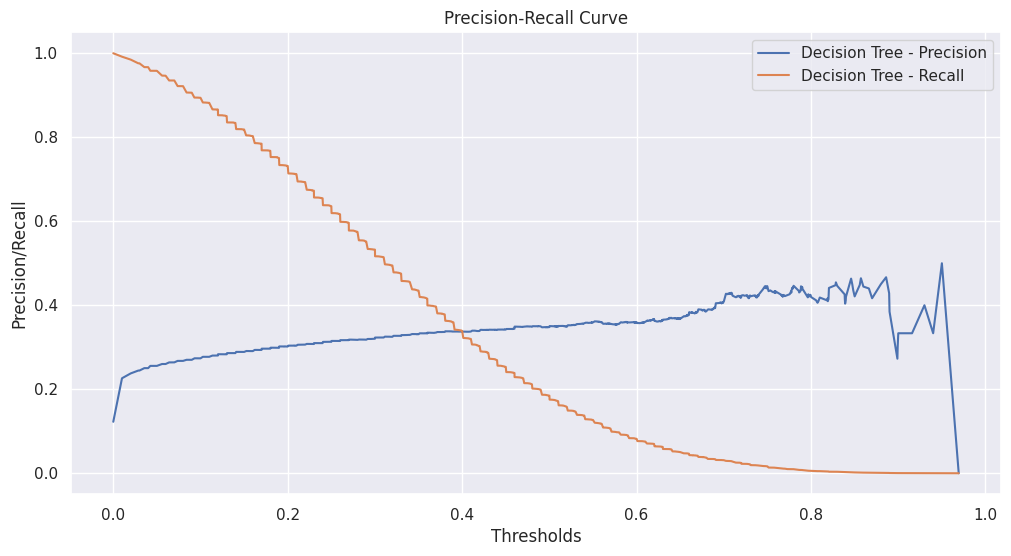

In [69]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

content = plot_precision_recall_curve(ax,
    dataset_train = (x_train_tomek, y_train_tomek),
    dataset_test  = (X_test, y_test),
    model = rf_tomek,
    title = 'Decision Tree'
)

#### 3.3.3 - Embeded model (estratégia propria) - Bonus (Ciclo 2)

A estratégia baseia-se em realizar diversos treinamentos, onde a cada novo treinamento havera um processo de amostratgem boostrap para a classe majoritaria e minoritaria, porém este processo sera realizado em um dataset equilibrado. 

**Exemplo:**

5k amostras classe 1 vs 100k amostras classe 2. 

* Cria-se um dateset, que recebe todas as amostras da classe 1, e uma amostragem aleatória da classe 2, contendo 5k elementos. 
* Realiza-se o treinamento com este subset (que pode receber 5k c1 e os 5k c2 ou, 3k c1 (amostragem por bootstrap) e 3kc2 (subamostragem por bootstrap)). 
* Cada contribui com a probabilidade do elemento pertecenter a uma das classes. 
* O resultado é dado pela média de probabilidades. 
    

# 5 - Treinamento dos modelos

**Ciclo 1:**
    
- KNN
- Logistic Regression 
- Random forest
- xGBoost
- Neural Networks

In [70]:
def run_model_training(
        curr_dataset_train,
        dataset_test,
        dataset_valid
):
        X_train, y_train = curr_dataset_train
        X_test,  y_test  = dataset_test
        X_valid, y_valid = dataset_valid

        # ------------------------------------------------------------
        print('Running Random Forest...')
        rf_model = RandomForestClassifier(criterion='gini',
                                n_estimators=100,
                                max_depth=48,
                                n_jobs=-1,
                                class_weight='balanced',
                                max_features='log2',
                                bootstrap=True
                                ,max_samples=0.8
                                )
        rf_model.fit(X = X_train,
                y = y_train)
        metrics_rf = du.computeMetricsSklearnModel(model = rf_model,
                        dataset_train = (X_train, y_train),
                        dataset_test  = (X_test, y_test),
                        dataset_valid =  (X_valid, y_valid))
        metrics_rf = pd.DataFrame(metrics_rf)

        probas_rf = rf_model.predict_proba(X_test)[:,1]
        metrics_rf['model'] = 'Random Forest'
        metrics_rf = get_top_k_metrics(
                df_metrics=metrics_rf,
                y_proba=probas_rf,
                y_test=y_test
        )
        
        # ------------------------------------------------------------
        print('Running Logistic Regression...')
        logistic_model = LogisticRegression(class_weight='balanced')
        logistic_model.fit(
                           X = X_train,
                           y = y_train
                        ) 
        metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_lr = pd.DataFrame(metrics_lr)
        metrics_lr['model'] = 'Logistic Regression'

        probas_lr = logistic_model.predict_proba(X_test)[:,1]
        metrics_lr = get_top_k_metrics(
                df_metrics=metrics_lr,
                y_proba=probas_lr,
                y_test=y_test
        )

        # ------------------------------------------------------------
        print('Running KNN...')
        knn = KNeighborsClassifier(n_neighbors=5,
                                   n_jobs=-1)
        knn.fit(X = X_train, y = y_train)
        metrics_knn = du.computeMetricsSklearnModel(model = knn,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_knn = pd.DataFrame(metrics_knn)
        metrics_knn['model'] = 'KNN'

        probas_knn = knn.predict_proba(X_test)[:,1]
        metrics_knn = get_top_k_metrics(
                df_metrics=metrics_knn,
                y_proba=probas_knn,
                y_test=y_test
        )

        # --------------------------------------------------------------
        print('Running XGBoost...')
        xGboost = XGBClassifier(
                objective='binary:logistic',
                n_estimators=30,
                max_depth=6,
                learning_rate=0.1
        )

        xGboost.fit(X = X_train, y = y_train)
        metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_xgboost = pd.DataFrame(metrics_xgboost)
        metrics_xgboost['model'] = 'XGBoost'

        probas_xgboost = xGboost.predict_proba(X_test)[:,1]
        metrics_xgboost = get_top_k_metrics(
                df_metrics=metrics_xgboost,
                y_proba=probas_xgboost,
                y_test=y_test
        )


        metrics_all = pd.concat([metrics_rf, metrics_lr, metrics_xgboost, metrics_knn], axis=0)
        metrics_all.sort_values(by=['f1_score'], ascending=False)

        models = {
                'random_forest' : rf_model,
                'logistic_regression' : logistic_model,
                'xgboost' : xGboost,
                'knn' : knn
        }
        return models, metrics_all



In [129]:
models, metrics_smote= run_model_training(
      curr_dataset_train = (X_train_smote, y_train_smote),
        dataset_test = (X_test, y_test),
        dataset_valid = (X_valid, y_valid)
)

Running Random Forest...
Running Logistic Regression...
Running KNN...
Running XGBoost...


In [133]:
models, metrics_ros= run_model_training(
      curr_dataset_train = (X_train_ros, y_train_ros),
        dataset_test = (X_test, y_test),
        dataset_valid = (X_valid, y_valid)
)

Running Random Forest...
Running Logistic Regression...
Running KNN...
Running XGBoost...


In [130]:
models, metrics_all = run_model_training(
      curr_dataset_train = (X_train, y_train),
        dataset_test = (X_test, y_test),
        dataset_valid = (X_valid, y_valid)
)

Running Random Forest...
Running Logistic Regression...
Running KNN...
Running XGBoost...


In [ ]:
metrics_all['method'] = 'No Sampling'
metrics_smote['method'] = 'SMOTE'
metrics_ros['method'] = 'Random Over Sampling'
metrics_final = pd.concat([metrics_all, metrics_smote, metrics_ros], axis=0)

metrics_final[metrics_final.index.isin(['train','valid'])][['method','accuracy', 'precision', 'recall', 
                                                            'model', 'precision_top_20000', 'dataset_abrangence_r80']].sort_values(by=['model', 'precision_top_20000', 'method'], ascending=[False, False, False])


,method,accuracy,precision,recall,model,precision_top_20000,dataset_abrangence_r80
train,SMOTE,0.785972,0.718131,0.941475,XGBoost,0.28880,0.346523
valid,SMOTE,0.668116,0.261482,0.936024,XGBoost,0.28880,0.346523
train,No Sampling,0.877450,0.666667,0.000198,XGBoost,0.28855,0.346643
valid,No Sampling,0.877382,0.000000,0.000000,XGBoost,0.28855,0.346643
train,Random Over Sampling,0.784499,0.718497,0.935535,XGBoost,0.28685,0.346928
valid,Random Over Sampling,0.670395,0.262439,0.932966,XGBoost,0.28685,0.346928
train,SMOTE,0.793917,0.725046,0.946931,Random Forest,0.28825,0.349957
valid,SMOTE,0.673259,0.262148,0.917920,Random Forest,0.28825,0.349957
train,No Sampling,0.677878,0.267450,0.936300,Random Forest,0.28810,0.349777
valid,No Sampling,0.674773,0.263176,0.918654,Random Forest,0.28810,0.349777


**A aplicação do SMOTE para orversampling, não gerou contribuição real para o aprendizado com objetivo de ranking, gerando um overfitting dos modelos na tarefa de classificação**

### Neural network

* Input (n_features)
* Hidden_1 (n_features * 4)
* Hidden_2 (2)

In [64]:
class NeuralNetworkModel(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetworkModel, self).__init__()
        self.input = nn.Linear(input_size, input_size*4)
        self.hidden1 = nn.Linear(input_size*4, input_size*2)
        self.output = nn.Linear(input_size*2, 1)

    def forward(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.hidden1(x)
        x = F.relu(x)
        x = self.output(x)
        x = F.sigmoid(x)
        return x

In [65]:
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1) 
train_tensor_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor  = torch.FloatTensor(X_test.values)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1,1)

test_tensor_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [43]:

def get_test_loss(
        model, 
        test_dataset,
        criterion
):
    test_loss = []
    model.eval()
    with torch.no_grad():
        for data, target in test_dataset:
            output = model(data)
            loss = criterion(output, target)
            test_loss.append(loss.item())
    
    return np.mean(test_loss)

def train_neural_network(
        model, 
        train_dataset,
        test_dataset,
        optimizer,
        criterion,
        epochs : int = 10
):  
    train_loss = []
    train_loss_epoch = []
    test_loss_epoch = []
    for epoch in tqdm(range(0,epochs)):
        model.train()

        for data, target in train_dataset:
            optimizer.zero_grad()
            output = model(data)
            loss   = criterion(output, target)
            loss.backward()

            optimizer.step()

            train_loss.append(loss.item())
       
        train_loss_epoch.append(np.mean(train_loss))

        test_loss = get_test_loss(
            model=model,
            test_dataset=test_dataset,
            criterion=criterion
        )
        test_loss_epoch.append(test_loss)

        if epoch % 20 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
            print(f'Epoch {epoch}, Test Loss: {test_loss}')
            
    
    plt.plot(train_loss_epoch, label='Train Loss')
    plt.plot(test_loss_epoch, label='Test Loss')
    plt.legend()
    plt.show()

    return model, train_loss 

  2%|▏         | 1/60 [00:01<01:53,  1.92s/it]

Epoch 0, Loss: 0.4218328893184662
Epoch 0, Test Loss: 0.4446044921875


 35%|███▌      | 21/60 [00:34<01:03,  1.63s/it]

Epoch 20, Loss: 0.349632203578949
Epoch 20, Test Loss: 0.37520394325256345


 68%|██████▊   | 41/60 [01:05<00:29,  1.54s/it]

Epoch 40, Loss: 0.3608883321285248
Epoch 40, Test Loss: 0.3277774830659231


100%|██████████| 60/60 [01:35<00:00,  1.59s/it]


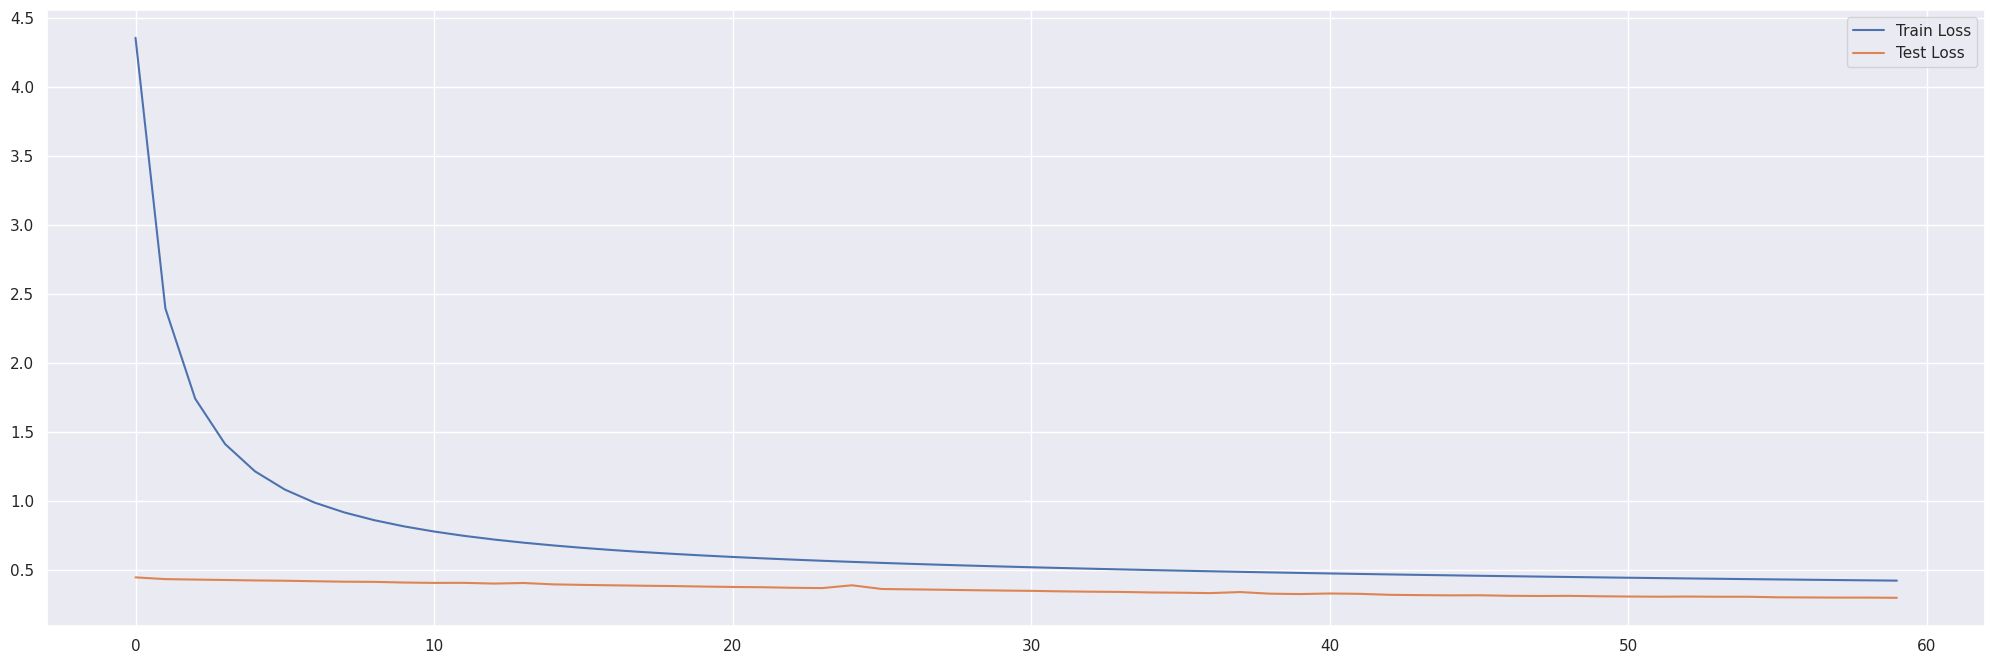

In [67]:
model = NeuralNetworkModel(input_size=X_train.shape[1])
criterion = nn.BCELoss() 
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=1e-4)



batch_size = 2056
train_dataloader = DataLoader(train_tensor_dataset,
                           batch_size=batch_size,
                           num_workers=4,
                           shuffle=True)

test_dataloader = DataLoader(test_tensor_dataset,
                            batch_size=batch_size,
                            num_workers=0,
                            shuffle=False)

model, train_loss = train_neural_network(
    model = model,
    train_dataset = train_dataloader,
    test_dataset= test_dataloader,
    optimizer = optimizer,
    criterion = criterion,
    epochs = 60
)

In [68]:
df_nn_metrics = get_top_k_metrics(pd.DataFrame({'model' : 'NeuralNetworkModel'},index=[0]),
                    y_proba  = model(X_test_tensor).detach().numpy().reshape(-1),
                    y_test = y_test)

metrics_all = pd.concat([metrics_all, df_nn_metrics], axis=0)
metrics_all.sort_values(by=['precision_top_20000'], ascending=False)

NameError: name 'get_top_k_metrics' is not defined

In [ ]:
predictions_nn = model(X_test_tensor).detach().numpy().reshape(-1)
predictions_rf = models['random_forest'].predict_proba(X_test)[:,1]
predictions_xg = models['xgboost'].predict_proba(X_test)[:,1]
predictions_lr = models['logistic_regression'].predict_proba(X_test)[:,1]


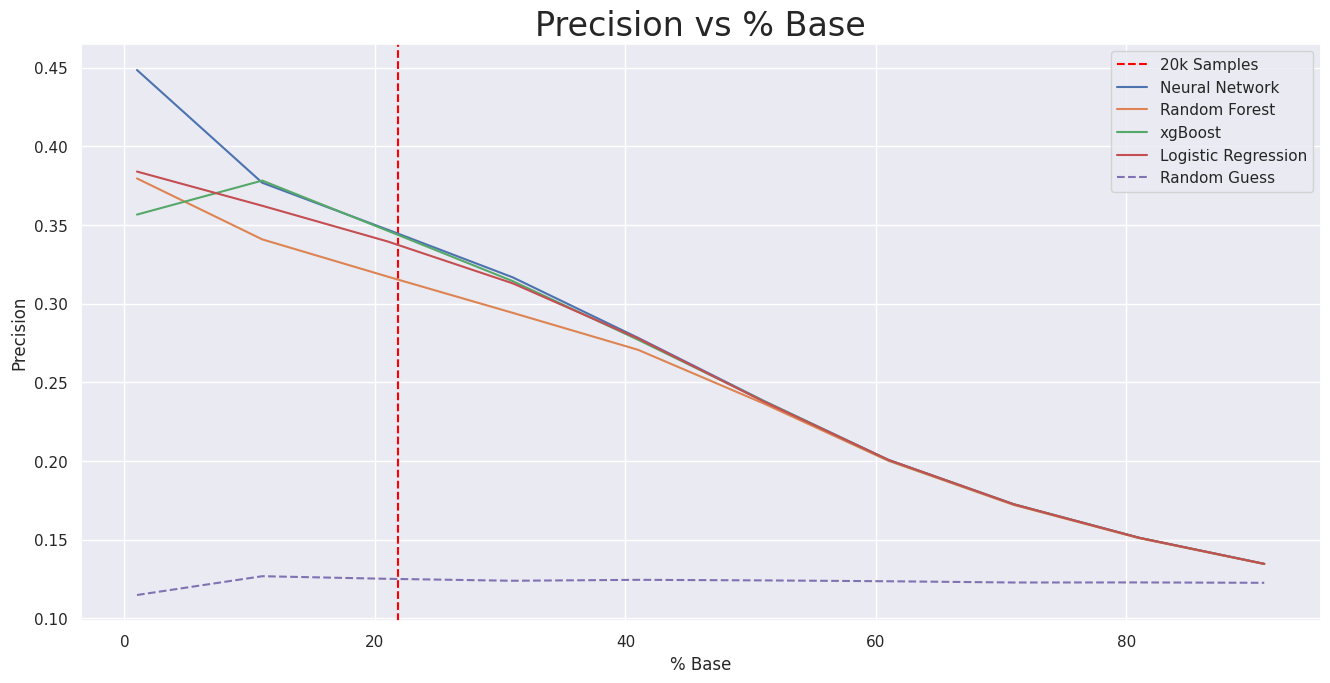

In [ ]:
plt.figure(figsize=(16,7.5))
plt.axvline(x=20e3/len(y_test)*100, color='red', linestyle='--', label='20k Samples')
percentis_nn, precisions_nn             =  plot_precision_top_k(y_proba=predictions_nn, y_true=y_test.values, label ='Neural Network')
percentis_rf, precisions_rf             =  plot_precision_top_k(y_proba=predictions_rf, y_true=y_test.values, label ='Random Forest')
percentis_xgboost, precisions_xgboost   =  plot_precision_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_lr, precisions_lr             =  plot_precision_top_k(y_proba=predictions_lr, y_true=y_test.values, label ='Logistic Regression')




In [ ]:
df_3.Annual_Premium.describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

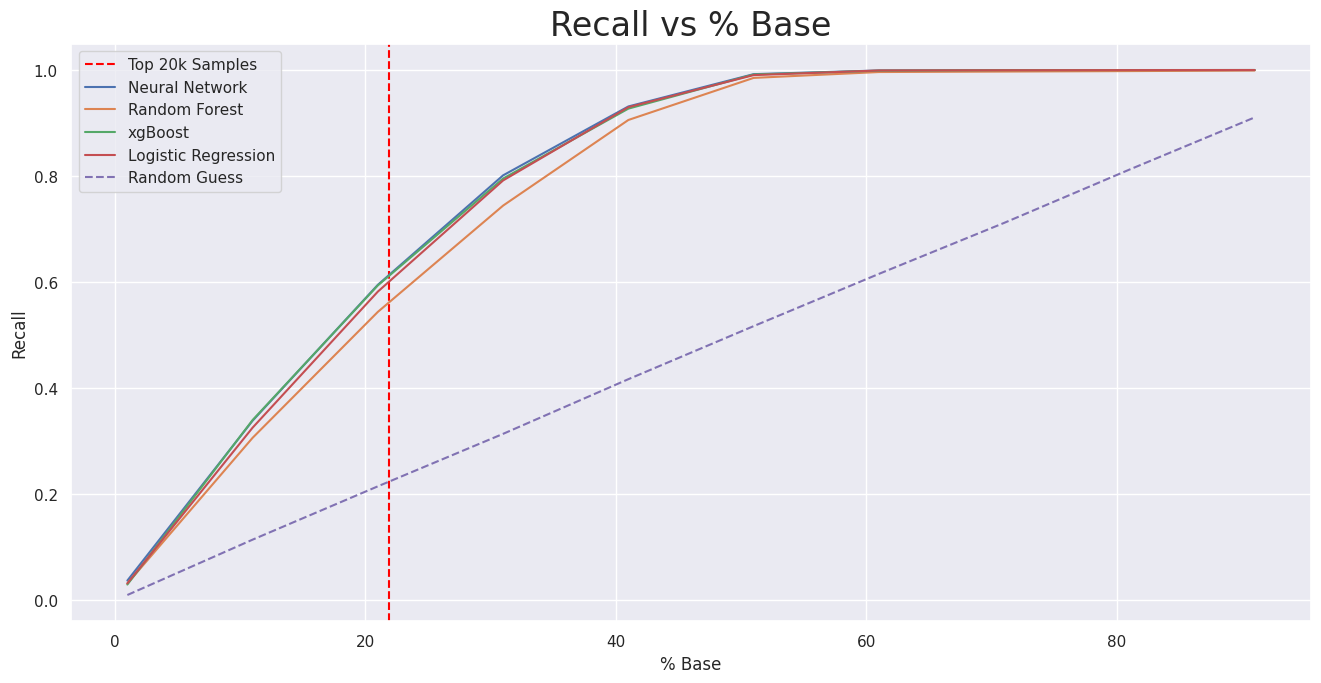

In [ ]:
plt.figure(figsize=(16,7.5))

plt.axvline(x=20e3/len(X_test)*100, color='red', linestyle='--', label='Top 20k Samples')
percentis_nn, recalls_nn =     plot_recall_top_k(y_proba=predictions_nn, y_true=y_test.values, label ='Neural Network')
percentis_rf, recalls_rf =     plot_recall_top_k(y_proba=predictions_rf, y_true=y_test.values, label ='Random Forest')
percentis_xgboost, recalls_xgboost =     plot_recall_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_lr, recalls_lr =     plot_recall_top_k(y_proba=predictions_lr, y_true=y_test.values, label ='Logistic Regression')


**Modelos elegíveis ao fine tuning:**
 * Redes Neurais
 * XGBosst

### 4.2 - Fine Tuning

#### 4.2.1 - XGboost

In [71]:
def train_xgboost(
        estimators      : int, 
        max_depth       : int, 
        learning_rate   : int,
        dataset_train   : list, 
        dataset_test    : list,
        dataset_valid   : list
):
    _x_train, _y_train              = dataset_train 
    _x_test, _y_test                = dataset_test
    _x_valid, _y_valid              = dataset_valid

    
    xGboost = XGBClassifier(
                    objective='binary:logistic',
                    n_estimators=estimators,
                    max_depth=max_depth,
                    learning_rate=learning_rate,
                    n_jobs = -1
            )

    xGboost.fit(X = _x_train, y = _y_train)
    
    metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                            dataset_train = dataset_train,
                            dataset_test  = dataset_test,
                            dataset_valid =  dataset_valid)
    
    metrics_xgboost = pd.DataFrame(metrics_xgboost)
    metrics_xgboost['model'] = 'XGBoost'
    metrics_xgboost['parameters'] = f'n_estimators={estimators}, max_depth={depth}, learning_rate={lr}'

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(_x_train)[:,1],
                                        y_test=_y_train,
                                        set_of_data='_train')
    
    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(_x_test)[:,1],
                                        y_test=_y_test,
                                        set_of_data='_test')

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(_x_valid)[:,1],
                                        y_test=_y_valid,
                                        set_of_data='_valid')
    
    return metrics_xgboost

In [72]:
lrs = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
n_estimators = [30, 60, 100, 120, 210]
depths = [4, 8, 12]

metrics_xgboost_list = []
cont = 0
for depth in tqdm(depths):
    for estimators in n_estimators:
        for lr in lrs:
            print(f'Running {cont}/{len(depths) * len(n_estimators) * len(lrs)}: n_estimators={estimators}, max_depth={depth}, learning_rate={lr}')
            cont += 1
            xGboost = XGBClassifier(
                    objective='binary:logistic',
                    n_estimators=estimators,
                    max_depth=depth,
                    learning_rate=lr,
                    n_jobs = -1
            )

            xGboost.fit(X = X_train, y = y_train)
            metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                                    dataset_train = (X_train, y_train),
                                    dataset_test  = (X_test, y_test),
                                    dataset_valid =  (X_valid, y_valid))
            metrics_xgboost = pd.DataFrame(metrics_xgboost)
            metrics_xgboost['model'] = 'XGBoost'
            metrics_xgboost['parameters'] = f'n_estimators={estimators}, max_depth={depth}, learning_rate={lr}'


                             
            metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                                y_proba=xGboost.predict_proba(X_train)[:,1],
                                                y_test=y_train,
                                                set_of_data='_train')
            
            metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                                y_proba=xGboost.predict_proba(X_test)[:,1],
                                                y_test=y_test,
                                                set_of_data='_test')

            metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                                y_proba=xGboost.predict_proba(X_valid)[:,1],
                                                y_test=y_valid,
                                                set_of_data='_valid')
            
            metrics_xgboost_list.append(metrics_xgboost)



    
    metrics_xgboost_list.append(metrics_xgboost)

  0%|          | 0/3 [00:00<?, ?it/s]

Running 0/90: n_estimators=30, max_depth=4, learning_rate=0.01


/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Running 1/90: n_estimators=30, max_depth=4, learning_rate=0.1


/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Running 67/90: n_estimators=60, max_depth=12, learning_rate=0.1
Running 68/90: n_estimators=60, max_depth=12, learning_rate=0.2
Running 69/90: n_estimators=60, max_depth=12, learning_rate=0.3
Running 70/90: n_estimators=60, max_depth=12, learning_rate=0.4
Running 71/90: n_estimators=60, max_depth=12, learning_rate=0.5
Running 72/90: n_estimators=100, max_depth=12, learning_rate=0.01


/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/p123/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Running 73/90: n_estimators=100, max_depth=12, learning_rate=0.1
Running 74/90: n_estimators=100, max_depth=12, learning_rate=0.2
Running 75/90: n_estimators=100, max_depth=12, learning_rate=0.3
Running 76/90: n_estimators=100, max_depth=12, learning_rate=0.4
Running 77/90: n_estimators=100, max_depth=12, learning_rate=0.5
Running 78/90: n_estimators=120, max_depth=12, learning_rate=0.01
Running 79/90: n_estimators=120, max_depth=12, learning_rate=0.1
Running 80/90: n_estimators=120, max_depth=12, learning_rate=0.2
Running 81/90: n_estimators=120, max_depth=12, learning_rate=0.3
Running 82/90: n_estimators=120, max_depth=12, learning_rate=0.4
Running 83/90: n_estimators=120, max_depth=12, learning_rate=0.5
Running 84/90: n_estimators=210, max_depth=12, learning_rate=0.01
Running 85/90: n_estimators=210, max_depth=12, learning_rate=0.1
Running 86/90: n_estimators=210, max_depth=12, learning_rate=0.2
Running 87/90: n_estimators=210, max_depth=12, learning_rate=0.3
Running 88/90: n_estima

100%|██████████| 3/3 [02:04<00:00, 41.57s/it]


In [73]:
xgBoostResults = pd.concat(metrics_xgboost_list).reset_index(drop = False)
xgBoostResults.rename(columns = {'index' : 'dataset'}, inplace = True)

**Best Test Parameters**

In [74]:
showColumns = ['parameters','dataset_abrangence_r80_train','dataset_abrangence_r80_valid',
               'precision_top_1000_train','precision_top_1000_valid', 'precision_top_20000_train','precision_top_20000_valid', 'precision_top_20000_test' ,
               'dataset_abrangence_r80_train', 'dataset_abrangence_r80_valid']

In [84]:
xgBoostResults[xgBoostResults.dataset == 'valid'][showColumns].sort_values(by=['precision_top_20000_valid'], ascending=False).head(5)

,parameters,dataset_abrangence_r80_train,dataset_abrangence_r80_valid,precision_top_1000_train,precision_top_1000_valid,precision_top_20000_train,precision_top_20000_valid,precision_top_20000_test,dataset_abrangence_r80_train,dataset_abrangence_r80_valid
47,"n_estimators=100, max_depth=4, learning_rate=0.3",0.297945,0.306560,0.589,0.431,0.42825,0.32145,0.31960,0.297945,0.306560
65,"n_estimators=120, max_depth=4, learning_rate=0.3",0.296032,0.307339,0.603,0.419,0.43290,0.32135,0.31995,0.296032,0.307339
101,"n_estimators=30, max_depth=8, learning_rate=0.2",0.296730,0.308254,0.613,0.428,0.42580,0.32125,0.31880,0.296730,0.308254
62,"n_estimators=120, max_depth=4, learning_rate=0.2",0.300190,0.307999,0.589,0.428,0.42240,0.32120,0.31990,0.300190,0.307999
32,"n_estimators=60, max_depth=4, learning_rate=0.4",0.299277,0.308134,0.567,0.425,0.42415,0.32100,0.31870,0.299277,0.308134


In [76]:
xgBoostResults[xgBoostResults.dataset == 'valid'].precision_top_20000_valid.describe()

count    93.000000
mean      0.315023
std       0.006035
min       0.298950
25%       0.311800
50%       0.317250
75%       0.319550
max       0.321450
Name: precision_top_20000_valid, dtype: float64

**Best parameters:**

* n_estimators=30, 
* max_depth=8, 
* learning_rate=0.2

#### 4.2.3 - Neural Network

In [45]:
from typing import Literal

class CustomNeuralNetworkModel(nn.Module):
    def __init__(self, 
                input_size,
                model_selected : Literal[1,2,3] = 1,
                out_1 : int = 64,
                out_2 : int = 32,
                out_3 : int = 1):
        
        super(CustomNeuralNetworkModel, self).__init__()
        self.input      = nn.Linear(input_size, out_1)
        self.hidden1    = nn.Linear(out_1, out_2)
        self.output     = nn.Linear(out_2, out_3)
        self.model_selected = model_selected
    
    
    def forward_1(self, x):
         x = self.forward_default(x) 
         return F.sigmoid(x) 
    
    def forward_2(self, x):
         x = self.forward_default(x) 
         return F.softmax(x) 
    
    def forward_default(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.hidden1(x)
        x = F.relu(x)
        x = self.output(x)
        
        return x
    
    def forward(self, x):
        if self.model_selected == 1:
            return self.forward_1(x)
        
        elif self.model_selected == 2:
            return self.forward_2(x)
    



In [ ]:
batch_sizes = [1028,2056,5112]

X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).reshape(-1,1).reshape(-1) 
train_tensor_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor  = torch.FloatTensor(X_test.values)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long).reshape(-1,1)

test_tensor_dataset = TensorDataset(X_test_tensor, y_test_tensor.reshape(-1))

train_dataloader = DataLoader(train_tensor_dataset,
                        batch_size=batch_size,
                        num_workers=4,
                        shuffle=True)

test_dataloader = DataLoader(test_tensor_dataset,
                            batch_size=batch_size,
                            num_workers=0,
                            shuffle=False)

In [ ]:

lower_network  = [16,8,2]
medium_network = [32,16,2]
higher_network = [128,64,2]
ballom_network = [16,64,2]
networks = [lower_network, medium_network, higher_network, ballom_network]  

lrs = [1e-4, 1e-3]
networks = [lower_network, medium_network, higher_network, ballom_network]  

# Definindo pessos inversamente proporcionais à frequência das classes
loss_weigths_balanced = torch.FloatTensor([1 - y_train.value_counts()[0] / len(y_train),               
                1 - y_train.value_counts()[1] / len(X_train)])

loss_weitghs_default = torch.FloatTensor([0.5, 0.5])


loss_weitghs_list = [loss_weigths_balanced, loss_weitghs_default]
networks = [lower_network, medium_network, higher_network]





In [ ]:
y_train_tensor = y_train_tensor.reshape(-1).reshape(-1)
y_train_tensor.size()

torch.Size([228665])

In [ ]:
def run_experiment_set_with_neural(model_path : str,
                               results_path : str,
                               architectures : list,
                               epochs_experiment : int = 10):

    metrics_nn_list = []
    batch_sizes = [1028,2056,5112]

    print('ahoyy')
    print(networks)
    for model_definition in tqdm(architectures):
        for loss_weigth in loss_weitghs_list:
            for lr in lrs:
                for batch_size in batch_sizes:

                    train_dataloader = DataLoader(train_tensor_dataset,
                                            batch_size=batch_size,
                                            num_workers=4,
                                            shuffle=True)

                    test_dataloader = DataLoader(test_tensor_dataset,
                                                batch_size=batch_size,
                                                num_workers=0,
                                                shuffle=False)
                    model_name = '_'.join([str(x) for x in model_definition]) + f'_lr_{lr}_batch_size_{batch_size}_weigth_{loss_weigth[-1]}'
                    
                    
                    print('-'*64)
                    print(f'Running model with architecture {model_definition} - loss weights {loss_weigth} - lr {lr} - batch_size {batch_size}')
                    print('-'*64)

                    out_1, out_2, out_3 = model_definition
                    model = CustomNeuralNetworkModel(
                                input_size=X_train.shape[1], 
                                model_selected=2,
                                out_1=out_1,
                                out_2=out_2, 
                                out_3=out_3
                            )
                    
                    criterion = nn.CrossEntropyLoss(weight=loss_weigth) 
                    #criterion = nn.BCELoss()
                    optimizer = torch.optim.Adam(model.parameters(), 
                                                lr=lr)



                    model, train_loss = train_neural_network(
                        model = model,
                        train_dataset = train_dataloader,
                        test_dataset= test_dataloader,
                        optimizer = optimizer,
                        criterion = criterion,
                        epochs = epochs_experiment
                    )

                    
                    metrics_nn = {}
                    metrics_nn['model'] = 'NeuralNetwork'
                    metrics_nn['parameters'] = f'model_layers={model_definition}, loss_weigth={loss_weigth.detach().numpy()}, learning_rate={lr}, batch_size={batch_size}'
                    #metrics_nn = pd.DataFrame(metrics_nn, index=[0])
                    print('Predicting test values...')
                    model.eval()
                    y_nn_proba = model(X_test_tensor)[:,1].detach().cpu().numpy()
                    metrics_nn = get_top_k_metrics(df_metrics=metrics_nn,
                                                        y_proba=y_nn_proba,
                                                        y_test=y_test)
                    
                    model_path_ = os.path.join(model_path, model_name) + '.pth'
                    torch.save(model.state_dict(),model_path_)
                    metrics_nn['train_loss'] = train_loss

                    print('Model experiment saved at: {model_path}')
                    metrics_nn['model_path'] = model_path_ 


                    with open(os.path.join(results_path, 
                                        model_name + '.json'), 'w') as f:
                        
                        json.dump(metrics_nn, f)

                    print('Results experiment saved at: {results_path}')

                    metrics_nn_list.append(metrics_nn)
            
        df_results = pd.DataFrame(metrics_nn_list)
        df_results.to_json(os.path.join(results_path, 'general_results.json'))
        
    return metrics_nn_list


In [ ]:
batch_sizes = [1028,2056,5112]

lower_network  = [16,8,2]
medium_network = [32,16,2]
higher_network = [128,64,2]
ballom_network = [16,64,2]
networks = [lower_network, medium_network, higher_network, ballom_network]  

run_experiment_set_with_neural(model_path = '../models/definition',
                           results_path= '../models/results',
                           epochs_experiment=60,
                           architectures=networks)

### 4.3 - Results 
**Champion model: XGboost, overcoming neural networks over all metrics**

* Compare neural network with xgboost using those metrics: 
    1. precision_top_20k_samples
    2. precision_top_1k_samples
    3. Dataset_Coverage_up_2_80%
    4. Overfiting bias




In [ ]:
df_list = []
for nm in tqdm(os.listdir('../models/results/')):
    if nm != 'general_results.json':
        fPath = os.path.join('../models/results/',nm)
        df_read = pd.read_json(fPath)
        df_read['fPath'] = fPath
        df_list.append(df_read)



In [ ]:

nn_results = pd.concat(df_list)
nn_results = nn_results.drop(columns='train_loss')
nn_results = nn_results.drop_duplicates()
nn_results = nn_results.sort_values(by = 'precision_top_20000', ascending=False)
nn_results.head(3)


,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000,model_path,fPath
0,NeuralNetwork,"model_layers=[128, 64, 2], loss_weigth=[0.1225...",0.308246,1,0.2,0.40,0.380,0.34105,../models/definition/128_64_2_lr_0.001_batch_s...,../models/results/128_64_2_lr_0.001_batch_size...
0,NeuralNetwork,"model_layers=[16, 8, 2], loss_weigth=[0.122563...",0.309744,1,0.4,0.39,0.373,0.34085,../models/definition/16_8_2_lr_0.001_batch_siz...,../models/results/16_8_2_lr_0.001_batch_size_1...
0,NeuralNetwork,"model_layers=[32, 16, 2], loss_weigth=[0.12256...",0.311055,1,0.5,0.45,0.403,0.34040,../models/definition/32_16_2_lr_0.001_batch_si...,../models/results/32_16_2_lr_0.001_batch_size_...


In [ ]:

xgBoostResults[xgBoostResults.dataset == 'test'].sort_values(by=['precision_top_20000'], ascending=False).head(3)

,dataset,accuracy,precision,recall,f1_score,auc,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000
76,test,0.877495,0.516556,0.006958,0.013731,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.3",0.304802,1.0,0.5,0.53,0.481,0.35355
406,test,0.877419,0.496403,0.012310,0.024025,None,XGBoost,"n_estimators=100, max_depth=8, learning_rate=0.1",0.304692,1.0,0.7,0.51,0.447,0.35350
94,test,0.877419,0.487805,0.003568,0.007085,None,XGBoost,"n_estimators=80, max_depth=4, learning_rate=0.2",0.304113,1.0,0.7,0.46,0.493,0.35330


In [ ]:

xgBoostResults[xgBoostResults.dataset == 'valid'].sort_values(by=['precision_top_20000'], ascending=False).head(1)

,dataset,accuracy,precision,recall,f1_score,auc,model,parameters,dataset_abrangence_r80,dataset_abrangence_r100,precision_top_10,precision_top_100,precision_top_1000,precision_top_20000
77,valid,0.877644,0.56701,0.007359,0.014529,None,XGBoost,"n_estimators=60, max_depth=4, learning_rate=0.3",0.304802,1.0,0.5,0.53,0.481,0.35355


### 4.3 - Cross Validation

In [83]:
def train_xgboost(
        estimators      : int, 
        max_depth       : int, 
        learning_rate   : int,
        dataset_train   : list, 
        dataset_test    : list,
        dataset_valid   : list
):
    x_train, y_train              = dataset_train 
    x_test,  y_test               = dataset_test
    x_valid, y_valid              = dataset_valid

    
    xGboost = XGBClassifier(
                    objective='binary:logistic',
                    n_estimators=estimators,
                    max_depth=max_depth,
                    learning_rate=learning_rate,
                    n_jobs = -1
            )

    xGboost.fit(X = x_train, y = y_train)
    
    metrics_xgboost = du.computeMetricsSklearnModel(model = xGboost,
                            dataset_train = dataset_train,
                            dataset_test  = dataset_test,
                            dataset_valid =  dataset_valid)
    
    metrics_xgboost = pd.DataFrame(metrics_xgboost)
    metrics_xgboost['model'] = 'XGBoost'
    metrics_xgboost['parameters'] = f'n_estimators={estimators}, max_depth={max_depth}, learning_rate={learning_rate}'

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(x_train)[:,1],
                                        y_test=y_train,
                                        set_of_data='_train')
    
    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(x_test)[:,1],
                                        y_test=y_test,
                                        set_of_data='_test')

    metrics_xgboost = get_top_k_metrics(df_metrics=metrics_xgboost,
                                        y_proba=xGboost.predict_proba(x_valid)[:,1],
                                        y_test=y_valid,
                                        set_of_data='_valid')
    
    return metrics_xgboost

In [82]:
def evaluate_model(
        model_name      : str, 
        sklearn_model,
        model_params    : dict,
        dataset_train   : tuple, 
        dataset_test    : tuple,
        dataset_valid   : tuple
):
    '''
    -- evaluate some skelarn model
    args:
        model_name    : str -> nome do modelo a ser utilizado
        skelarn_model : skelarn.model -> modelo do formato sklearn a ser testado
        model_params  : dict -> dicionario com os respectivos parametros do modelo
        dataset_train : tuple -> x, y
        dataset_test  : tuple -> x, y
        dataset_valid : tuple -> x, y

    returns:
        return model results
    '''
    x_train, y_train              = dataset_train 
    x_test,  y_test               = dataset_test
    x_valid, y_valid              = dataset_valid

    
    metrics_model = du.computeMetricsSklearnModel(model = sklearn_model,
                            dataset_train = dataset_train,
                            dataset_test  = dataset_test,
                            dataset_valid =  dataset_valid)
    
    metrics_model = pd.DataFrame(metrics_model)
    metrics_model['model'] = model_name
    metrics_model['parameters'] = model_params

    metrics_model = get_top_k_metrics(df_metrics=metrics_model,
                                        y_proba=sklearn_model.predict_proba(x_train)[:,1],
                                        y_test=y_train,
                                        set_of_data='_train')
    
    metrics_model = get_top_k_metrics(df_metrics=metrics_model,
                                        y_proba=sklearn_model.predict_proba(x_test)[:,1],
                                        y_test=y_test,
                                        set_of_data='_test')

    metrics_model = get_top_k_metrics(df_metrics=metrics_model,
                                        y_proba=sklearn_model.predict_proba(x_valid)[:,1],
                                        y_test=y_valid,
                                        set_of_data='_valid')
    
    return metrics_model


def train_model(sklearn_model,
                model_params : dict, 
                model_name   : str,
                dataset_train : tuple, 
                dataset_test  : tuple,
                dataset_valid : tuple):
    
    '''
    returs:
        model trained, 
        results 
        
    train and evaluate some skelarn model
    '''
    model_evaluated = sklearn_model(**model_params)
    
    x_train, y_train = dataset_train
    
    model_evaluated.fit(x_train, y_train)

    results = evaluate_model(model_name=model_name, 
                      sklearn_model = model_evaluated, 
                      model_params  = model_params,
                      dataset_train = dataset_train,
                      dataset_test  = dataset_test,
                      dataset_valid = dataset_valid
                      )    
    
    return model_evaluated, results




def cross_validation(sklearn_model, 
                     dataset,
                     model_name : str = 'Default',
                     k_folds : int = 10,
                     model_params = dict
                     ):

    X, y = dataset



    k_fold = StratifiedKFold(n_splits=k_folds)
    folds = k_fold.split(X, y)
    results = []

    for train_idxs, test_idxs in tqdm(folds):
        x_train_current_fold = X.iloc[train_idxs]
        y_train_current_fold = y.iloc[train_idxs]

        x_test_current_fold = X.iloc[test_idxs]
        y_test_current_fold = y.iloc[test_idxs]


        _, isntance_results = train_model(
            sklearn_model=sklearn_model, 
            model_params=model_params, 
            model_name=model_name,
            dataset_train=(x_train_current_fold, y_train_current_fold),
            dataset_test=(x_test_current_fold, y_test_current_fold),
            dataset_valid=(X_valid, y_valid)

        )
      
        results.append(isntance_results)

    return results 
  



In [85]:
n_estimators    = 30
max_depth       = 8
learning_rate   = 0.2

best_xGboost_params = {
           'objective'      : 'binary:logistic',
           'n_estimators'   : n_estimators,
           'max_depth'      : max_depth,
           'learning_rate'  : learning_rate,
           'n_jobs'         : -1
}






results_cross = cross_validation(sklearn_model=XGBClassifier,
                                dataset = (X,y),
                                model_name='MyModel',
                                model_params=best_xGboost_params,
                                k_folds=6)
df_result_cross = pd.concat(results_cross)
df_result_cross

6it [00:08,  1.38s/it]


,accuracy,precision,recall,f1_score,auc,model,parameters,dataset_abrangence_r80_train,dataset_abrangence_r100_train,precision_top_10_train,precision_top_100_train,precision_top_1000_train,precision_top_20000_train,dataset_abrangence_r80_test,dataset_abrangence_r100_test,precision_top_10_test,precision_top_100_test,precision_top_1000_test,precision_top_20000_test,dataset_abrangence_r80_valid,dataset_abrangence_r100_valid,precision_top_10_valid,precision_top_100_valid,precision_top_1000_valid,precision_top_20000_valid
train,0.877764,0.742991,0.004085,0.008125,None,MyModel,NaN,0.299663,1.0,1.0,0.80,0.610,0.43115,0.303374,1.0,0.5,0.53,0.466,0.31945,0.300727,1.0,0.9,0.65,0.485,0.32660
test,0.877407,0.473684,0.002312,0.004602,None,MyModel,NaN,0.299663,1.0,1.0,0.80,0.610,0.43115,0.303374,1.0,0.5,0.53,0.466,0.31945,0.300727,1.0,0.9,0.65,0.485,0.32660
valid,0.877817,0.750000,0.004771,0.009481,None,MyModel,NaN,0.299663,1.0,1.0,0.80,0.610,0.43115,0.303374,1.0,0.5,0.53,0.466,0.31945,0.300727,1.0,0.9,0.65,0.485,0.32660
train,0.877641,0.748092,0.002518,0.005018,None,MyModel,NaN,0.298655,1.0,1.0,0.78,0.590,0.43370,0.308495,1.0,0.4,0.56,0.473,0.31520,0.301252,1.0,0.9,0.63,0.481,0.32600
test,0.877484,0.555556,0.001927,0.003840,None,MyModel,NaN,0.298655,1.0,1.0,0.78,0.590,0.43370,0.308495,1.0,0.4,0.56,0.473,0.31520,0.301252,1.0,0.9,0.63,0.481,0.32600
valid,0.877787,0.833333,0.003670,0.007307,None,MyModel,NaN,0.298655,1.0,1.0,0.78,0.590,0.43370,0.308495,1.0,0.4,0.56,0.473,0.31520,0.301252,1.0,0.9,0.63,0.481,0.32600
train,0.877849,0.749049,0.005061,0.010054,None,MyModel,NaN,0.297889,1.0,1.0,0.88,0.640,0.43795,0.308653,1.0,0.4,0.40,0.430,0.31610,0.300067,1.0,1.0,0.68,0.508,0.32685
test,0.877279,0.380952,0.002055,0.004088,None,MyModel,NaN,0.297889,1.0,1.0,0.88,0.640,0.43795,0.308653,1.0,0.4,0.40,0.430,0.31610,0.300067,1.0,1.0,0.68,0.508,0.32685
valid,0.877937,0.793103,0.005627,0.011175,None,MyModel,NaN,0.297889,1.0,1.0,0.88,0.640,0.43795,0.308653,1.0,0.4,0.40,0.430,0.31610,0.300067,1.0,1.0,0.68,0.508,0.32685
train,0.877793,0.746725,0.004393,0.008735,None,MyModel,NaN,0.299253,1.0,1.0,0.88,0.597,0.43190,0.307110,1.0,0.6,0.43,0.450,0.31605,0.300142,1.0,0.8,0.61,0.488,0.32685


In [86]:
gp_df_result_cross = df_result_cross.iloc[:, 7:].drop_duplicates()
gp_df_result_cross.reset_index().rename(columns={'index' : 'dataset'}, inplace=True)
gp_df_result_cross = gp_df_result_cross.reset_index().rename(columns={'index' : 'dataset'})
gp_df_result_cross

,dataset,dataset_abrangence_r80_train,dataset_abrangence_r100_train,precision_top_10_train,precision_top_100_train,precision_top_1000_train,precision_top_20000_train,dataset_abrangence_r80_test,dataset_abrangence_r100_test,precision_top_10_test,precision_top_100_test,precision_top_1000_test,precision_top_20000_test,dataset_abrangence_r80_valid,dataset_abrangence_r100_valid,precision_top_10_valid,precision_top_100_valid,precision_top_1000_valid,precision_top_20000_valid
0,train,0.299663,1.0,1.0,0.80,0.610,0.43115,0.303374,1.0,0.5,0.53,0.466,0.31945,0.300727,1.0,0.9,0.65,0.485,0.32660
1,train,0.298655,1.0,1.0,0.78,0.590,0.43370,0.308495,1.0,0.4,0.56,0.473,0.31520,0.301252,1.0,0.9,0.63,0.481,0.32600
2,train,0.297889,1.0,1.0,0.88,0.640,0.43795,0.308653,1.0,0.4,0.40,0.430,0.31610,0.300067,1.0,1.0,0.68,0.508,0.32685
3,train,0.299253,1.0,1.0,0.88,0.597,0.43190,0.307110,1.0,0.6,0.43,0.450,0.31605,0.300142,1.0,0.8,0.61,0.488,0.32685
4,train,0.298491,1.0,1.0,0.85,0.582,0.43315,0.313014,1.0,0.6,0.54,0.440,0.31275,0.299978,1.0,0.8,0.62,0.498,0.32695
5,train,0.297943,1.0,0.9,0.84,0.601,0.43180,0.307629,1.0,0.6,0.49,0.429,0.31650,0.307804,1.0,0.6,0.47,0.437,0.32125


In [87]:
df_resumo = gp_df_result_cross.groupby('dataset').agg(
    # Nome_da_Nova_Coluna = ('Coluna_Original', 'Função_de_Agregação')
    
    abrangence_r80_train_mean=('dataset_abrangence_r80_train', 'mean'),
    abrangence_r80_train_std=('dataset_abrangence_r80_train', 'std'),
    abrangence_r80_train_min=('dataset_abrangence_r80_train', 'min'),
    abrangence_r80_train_max=('dataset_abrangence_r80_train', 'max'),

    abrangence_r80_test_mean=('dataset_abrangence_r80_test', 'mean'),
    abrangence_r80_test_std=('dataset_abrangence_r80_test', 'std'),
    abrangence_r80_test_min=('dataset_abrangence_r80_test', 'min'),
    abrangence_r80_test_max=('dataset_abrangence_r80_test', 'max'),


    abrangence_r80_valid_mean=('dataset_abrangence_r80_valid', 'mean'),
    abrangence_r80_valid_std=('dataset_abrangence_r80_valid', 'std'),
    abrangence_r80_valid_min=('dataset_abrangence_r80_valid', 'min'),
    abrangence_r80_valid_max=('dataset_abrangence_r80_valid', 'max'),


    precision_1k_test_mean=('precision_top_1000_test', 'mean'),
    precision_1k_test_std=('precision_top_1000_test', 'std'),
    precision_1k_test_min=('precision_top_1000_test', 'min'),
    precision_1k_test_max=('precision_top_1000_test', 'max'),

    precision_1k_valid_mean=('precision_top_1000_valid', 'mean'),
    precision_1k_valid_std=('precision_top_1000_valid', 'std'),
    precision_1k_valid_min=('precision_top_1000_valid', 'min'),
    precision_1k_valid_max=('precision_top_1000_valid', 'max'),

    precision_1k_train_mean=('precision_top_1000_train', 'mean'),
    precision_1k_train_std=('precision_top_1000_train', 'std'),
    precision_1k_train_min=('precision_top_1000_train', 'min'),
    precision_1k_train_max=('precision_top_1000_train', 'max'),

    precision_20k_test_mean=('precision_top_20000_test', 'mean'),
    precision_20k_test_std=('precision_top_20000_test', 'std'),
    precision_20k_test_min=('precision_top_20000_test', 'min'),
    precision_20k_test_max=('precision_top_20000_test', 'max'),

    precision_20k_valid_mean=('precision_top_20000_valid', 'mean'),
    precision_20k_valid_std=('precision_top_20000_valid', 'std'),
    precision_20k_valid_min=('precision_top_20000_valid', 'min'),
    precision_20k_valid_max=('precision_top_20000_valid', 'max'),

    precision_20k_train_mean=('precision_top_20000_train', 'mean'),
    precision_20k_train_std=('precision_top_20000_train', 'std'),
    precision_20k_train_min=('precision_top_20000_train', 'min'),
    precision_20k_train_max=('precision_top_20000_train', 'max'),


).reset_index()
df_resumo.T.reset_index().rename(columns={'index' : 'metric'})

,metric,0
0,dataset,train
1,abrangence_r80_train_mean,0.298649
2,abrangence_r80_train_std,0.000706
3,abrangence_r80_train_min,0.297889
4,abrangence_r80_train_max,0.299663
5,abrangence_r80_test_mean,0.308046
6,abrangence_r80_test_std,0.003102
7,abrangence_r80_test_min,0.303374
8,abrangence_r80_test_max,0.313014
9,abrangence_r80_valid_mean,0.301662


**Conclusions:**
    * The cross validation shows that the model has a stable behavior in some variaty of scenarios.Looking to abrangence_r80 metric, which  measure how much of my dataset in need to cover util reaching 80% of customers with intent to buy, the model follows both in train and valid ~ 31%. Which means that in dataset with 100 000 customers, and 20 000 with intent to buy, we need to reach out to 30 000 custumers to make 16 000 sales. 


**Obs:** The metric "precision_20k" in the test set is lower than train and valid set due to the sample test size. There aren't enough samples to reach the target of 20k customers with intent to buy 

## 5.5 - Salvando best Model 

In [88]:
X_train.columns = [x.lower() if x != 'sexo_feminino' else 'sexo_feminino_encoded' for x in X_train.columns ]
X_test.columns = [x.lower() if x != 'sexo_feminino' else 'sexo_feminino_encoded' for x in X_train.columns]
X_valid.columns = [x.lower() if x != 'sexo_feminino' else 'sexo_feminino_encoded' for x in X_train.columns]

In [89]:
X_train.columns

Index(['driving_license', 'previously_insured', 'region_code_encoded',
       'policy_sales_channel_encoded', 'vehicle_damage_encoded',
       'vintage_encoded', 'annual_premium_encoded', 'age_encoded'],
      dtype='object')

In [90]:
n_estimators    = 30
max_depth       = 8
learning_rate   = 0.2

best_xGboost_params = {
           'objective'      : 'binary:logistic',
           'n_estimators'   : n_estimators,
           'max_depth'      : max_depth,
           'learning_rate'  : learning_rate,
           'n_jobs'         : -1
}


# Now, i would be training the model with train and valid, cause i dont need more to do fine tuning. 
best_xGboost_to_prod ,results  = train_model(sklearn_model=XGBClassifier,
                           model_params=best_xGboost_params,
                           model_name='XGBOOST',
                           dataset_train=(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid])),
                           dataset_test=(X_test, y_test),
                           dataset_valid = (X_valid, y_valid))

joblib.dump(best_xGboost_to_prod, '../models/definition/xgboost/best_xgboost_model.pkl')
joblib.dump(best_xGboost_to_prod, '../src/app/model/resources/model_definition/best_xgboost_model.pkl')

['../src/app/model/resources/model_definition/best_xgboost_model.pkl']

In [91]:
propensity_to_by = best_xGboost_to_prod.predict_proba(X_test)[:,1]

dataset_estimations = df_raw.loc[X_test.index.values]
dataset_estimations['Propensity'] = propensity_to_by 
dataset_estimations.sort_values(by = 'Propensity', ascending = False, inplace=True)
dataset_estimations.head(12)




,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Propensity
57989,57990,Male,34,1,6.0,0,1-2 Year,Yes,27671.0,155.0,34,1,0.655919
103373,103374,Male,32,1,25.0,0,1-2 Year,Yes,192034.0,124.0,206,0,0.622200
167990,167991,Male,29,1,3.0,0,< 1 Year,Yes,29327.0,163.0,21,1,0.606982
73790,73791,Male,33,1,3.0,0,1-2 Year,Yes,32175.0,155.0,193,0,0.576495
158521,158522,Male,49,1,8.0,0,1-2 Year,Yes,35026.0,81.0,291,0,0.558179
134822,134823,Male,35,1,23.0,0,1-2 Year,Yes,28768.0,163.0,21,0,0.554477
148642,148643,Male,31,1,41.0,0,1-2 Year,Yes,27072.0,163.0,295,1,0.552922
365779,365780,Female,31,1,41.0,0,1-2 Year,Yes,21592.0,163.0,190,0,0.547743
349575,349576,Male,39,1,50.0,0,1-2 Year,Yes,54953.0,124.0,204,0,0.543205
73051,73052,Male,33,1,11.0,0,< 1 Year,Yes,21542.0,124.0,190,0,0.542691


**Saving list of predictions**

In [92]:
dataset_estimations.drop(columns=['Response']   , inplace=True)
dataset_estimations = dataset_estimations.iloc[:30000, :]
dataset_estimations.to_csv('../src/app/data/actions/insuranceHealthCross/results.csv',
                           index = False)

**Training the best model to evaluation front business models**

In [93]:
best_xGboost ,results  = train_model(sklearn_model=XGBClassifier,
                           model_params=best_xGboost_params,
                           model_name='XGBOOST',
                           dataset_train=(X_train, y_train),
                           dataset_test=(X_test, y_test),
                           dataset_valid = (X_valid, y_valid))

# 6. - Results/Estimated return

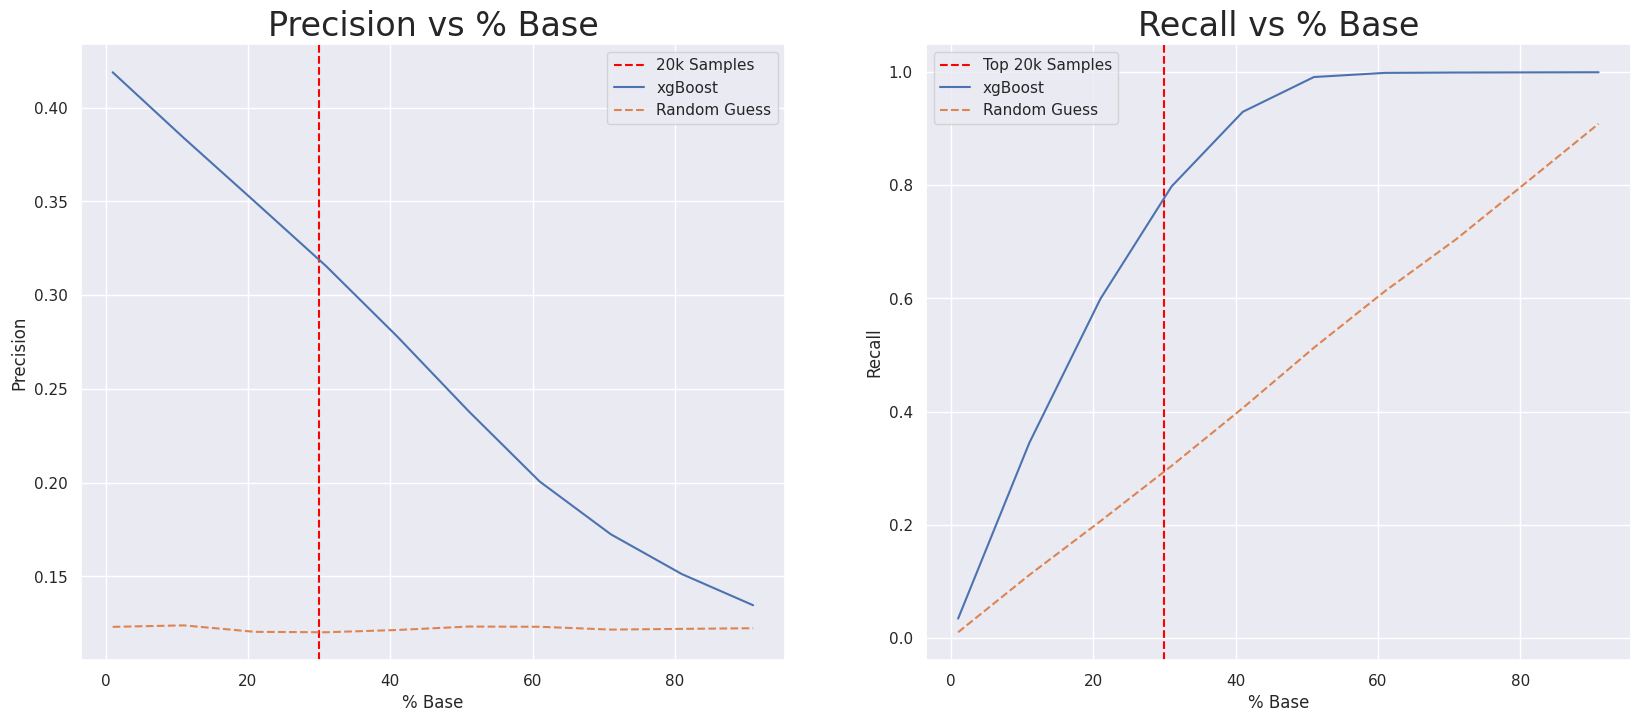

In [94]:
import random as rd 



rd.seed(43)

predictions_xg = best_xGboost.predict_proba(X_test)[:,1]
predictions_random = [rd.random() for x in range(len(X_test))]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,8))
plt.sca(ax1)
plt.axvline(x=20e3/len(y_test)*100, color='red', linestyle='--', label='20k Samples')
percentis_xgboost, precisions_xgboost   =  plot_precision_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_random, precisions_random     =  plot_precision_top_k(y_proba=predictions_random, y_true=y_test.values, label ='Random Guess', line_style='--')

plt.sca(ax2)
plt.axvline(x=20e3/len(X_test)*100, color='red', linestyle='--', label='Top 20k Samples')
percentis_xgboost, recalls_xgboost =     plot_recall_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_random, recalls_random = plot_recall_top_k(y_proba=predictions_random, y_true=y_test.values, label ='Random Guess', line_style='--')


### Simulations

Comparação de 3 modelos com a solução:

 * 1 - [Business] - Afraid:
     - Priority for customers that has vehicle damage = yes, previously_insured = no (has no one insurance vehicle) and older first 
     - Intuition: Older peoples has more stability and take more value for insurances and the afraid impact: peoples who have already experience some kind of accident and have no one insurance, has more propensity to buy some insurance. 

* 2 - [Business] - RFM Simplified 
    - Recence: Customers that has more time in our wallet has more points of relationship, and can have more propensity. (Greater Vintage) 
    -  Frequency: Channels/regions that has historicaly more sucess in conversions. 
    - Amount Value: Customers with a higher annual premium, can purchase more expansive insurance policies. 

* 3 - [Business] Demography. 
    - Customers of sex male and older, generally has more propenstity to buy a insurance vehicle. And for optimize the revenue of company, can be priorized customers with higher annual premium.

* 4 - [Machine Learning] - Use the machine learning algorithm treined.   


#### 1 - Afraid

In [95]:
def get_business_precision_top_k(
    top_k : int,
    df
):
    '''
    returns:
        precision_top_k_business : float -> precision top k with business perspective
    '''
    
    top_k = df.iloc[:top_k]
    precision_top_k = top_k.Response.sum() / len(top_k)
    return precision_top_k

In [106]:
df_simulation = df_3.loc[X_train.index.values]
df_simulation_test = df_3.loc[X_test.index.values]
df_simulation_valid = df_3.loc[X_valid.index.values]



In [107]:
df_simulation.head(3)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
223039,223040,Female,27,1,15.0,1,< 1 Year,No,33271.0,152.0,266,0
115344,115345,Female,23,1,8.0,1,< 1 Year,No,49054.0,152.0,146,0
337713,337714,Male,45,1,2.0,0,1-2 Year,Yes,2630.0,157.0,14,0


In [108]:
afraid = df_simulation.sort_values(by = ['Vehicle_Damage','Previously_Insured','Age'], ascending = [False, True, False])
afraid_top_20 = afraid.iloc[:20000]

afraid_test = df_simulation_test.sort_values(by = ['Vehicle_Damage','Previously_Insured','Age'], ascending = [False, True, False])
afraid_test['Proba'] = len(afraid_test) - afraid_test.reset_index().index.values

afraid_test_top_20 = afraid_test.iloc[:20000]

afraid_valid = df_simulation_valid.sort_values(by = ['Vehicle_Damage','Previously_Insured','Age'], ascending = [False, True, False])
afraid_valid_top_20 = afraid_valid.iloc[:20000]
afraid_valid['Proba'] = len(afraid_valid) - afraid_valid.reset_index().index.values

precision_top_k_business_test = get_business_precision_top_k(top_k=20000, df=afraid_test)
precision_top_k_business_valid = get_business_precision_top_k(top_k=20000, df=afraid_valid)
precision_top_k_business_train = get_business_precision_top_k(top_k=20000, df=afraid)

df_evaluation = pd.DataFrame({
    'model'   : ['Afraid_Business_Perspective', 'Afraid_Business_Perspective', 'Afraid_Business_Perspective'],
    'dataset' : ['train', 'test', 'valid'],
    'precision_top_k_business' : [precision_top_k_business_train, precision_top_k_business_test, precision_top_k_business_valid]
})

df_evaluation

,model,dataset,precision_top_k_business
0,Afraid_Business_Perspective,train,0.17655
1,Afraid_Business_Perspective,test,0.26760
2,Afraid_Business_Perspective,valid,0.26780


#### 2 - RFM Simplified

- Recence: Customers that has more time in our wallet has more points of relationship, and can have more propensity. (Greater Vintage) 
    -  Frequency: Channels/regions that has historicaly more sucess in conversions. 
    - Amount Value: Customers with a higher annual premium, can purchase more expansive insurance policies. 


In [109]:
# Ordena por idade
df_rfm_train = df_simulation.sort_values(by = ['Policy_Sales_Channel','Vintage'], ascending=False)
print(len(df_rfm_train))

#df_rfm_test = df_simulation_test.sort_values(by = ['Policy_Sales_Channel','Vintage'], ascending=False)
df_rfm_test = df_simulation_test.sort_values(by = ['Policy_Sales_Channel','Vintage'], ascending=False)
df_rfm_test['Proba'] = len(df_rfm_test) - df_rfm_test.reset_index().index.values

print(len(df_rfm_test)) 

df_rfm_valid = df_simulation_valid.sort_values(by = ['Policy_Sales_Channel','Vintage'], ascending=False)
print(len(df_rfm_valid))    

precision_top_k_business_test = get_business_precision_top_k(top_k=20000, df=df_rfm_test)
precision_top_k_business_valid = get_business_precision_top_k(top_k=20000, df=df_rfm_valid)
precision_top_k_business_train = get_business_precision_top_k(top_k=20000, df=df_rfm_train)

df_evaluation_rfm = pd.DataFrame({
    'model'   : ['RFM_Business_Perspective', 'RFM_Business_Perspective', 'RFM_Business_Perspective'],
    'dataset' : ['train', 'test', 'valid'],
    'precision_top_k_business' : [precision_top_k_business_train, precision_top_k_business_test, precision_top_k_business_valid]
})
df_evaluation_rfm


247720
66694
66695


,model,dataset,precision_top_k_business
0,RFM_Business_Perspective,train,0.09665
1,RFM_Business_Perspective,test,0.08420
2,RFM_Business_Perspective,valid,0.07960


#### 3 Demography. 

- Customers of sex male and older, generally has more propenstity to buy a insurance vehicle.

In [111]:
df_demographic_train = df_simulation[df_simulation.Gender == 'Male']
df_demographic = df_demographic_train.sort_values(by = ['Age'], ascending=False)

#df_demographic_test = df_simulation_test[df_simulation_test.sexo_feminino == 0]
df_demographic_test = df_simulation_test.sort_values(by = ['Gender','Age'], ascending=False)   
df_demographic_test['Proba'] = len(df_demographic_test) - df_demographic_test.reset_index().index.values

df_demographic_valid = df_simulation_valid[df_simulation_valid.Gender == 'Male']
df_demographic_valid = df_demographic_valid.sort_values(by = ['Age'], ascending=False) 

precision_top_k_business_test = get_business_precision_top_k(top_k=20000, df=df_demographic_test)
precision_top_k_business_valid = get_business_precision_top_k(top_k=20000, df=df_demographic_valid)
precision_top_k_business_train = get_business_precision_top_k(top_k=20000, df=df_demographic)

df_evaluation_demographic = pd.DataFrame({
    'model'   : ['Demographic_Business_Perspective', 'Demographic_Business_Perspective', 'Demographic_Business_Perspective'],
    'dataset' : ['train', 'test', 'valid'],
    'precision_top_k_business' : [precision_top_k_business_train, precision_top_k_business_test, precision_top_k_business_valid]
})
df_evaluation_demographic

,model,dataset,precision_top_k_business
0,Demographic_Business_Perspective,train,0.1089
1,Demographic_Business_Perspective,test,0.1794
2,Demographic_Business_Perspective,valid,0.1754


### 5.4 - Comparision

In [112]:
xGboost_precision_train = precision_top_k(top_k=20000, y_true=y_train.values, y_proba=best_xGboost.predict_proba(X_train)[:,1])
xGboost_precision_test = precision_top_k(top_k=20000, y_true=y_test.values, y_proba=best_xGboost.predict_proba(X_test)[:,1])
xGboost_precision_valid = precision_top_k(top_k=20000, y_true=y_valid.values, y_proba=best_xGboost.predict_proba(X_valid)[:,1])

df_evaluation_xgboost = pd.DataFrame({
    'model'   : ['XGBoost', 'XGBoost', 'XGBoost'],
    'dataset' : ['train', 'test', 'valid'],
    'precision_top_k_business' : [xGboost_precision_train, xGboost_precision_test, xGboost_precision_valid]
})
df_evaluation_xgboost

,model,dataset,precision_top_k_business
0,XGBoost,train,0.42580
1,XGBoost,test,0.31880
2,XGBoost,valid,0.32125


In [113]:
random_train = precision_top_k(top_k=20000, y_true=y_train.values, y_proba=[rd.random() for x in range(len(X_train))])
df_evaluation_random = pd.DataFrame({
    'model'   : ['Random Guess'],
    'dataset' : ['test'],
    'precision_top_k_business' : [random_train]
})
df_evaluation_random


,model,dataset,precision_top_k_business
0,Random Guess,test,0.1231


In [116]:
df_results_evaluation = pd.concat([df_evaluation, 
                                   df_evaluation_rfm, 
                                   df_evaluation_demographic, 
                                   df_evaluation_xgboost,
                                   df_evaluation_random], axis=0)

df_results_evaluation['customers'] = df_results_evaluation.precision_top_k_business.apply(lambda x: int(x*20000)) 
# valor estimado com base na media de seguro veicular no brasil
df_3['Annual_Premium_br'] = 2500

df_results_evaluation['Revenue'] = df_results_evaluation.customers * df_3.Annual_Premium_br.median()
df_results_evaluation['Revenue'] = df_results_evaluation['Revenue'].apply(lambda x: f'R$ {x:,.2f}'.replace(',','.'))
df_results_evaluation = df_results_evaluation.sort_values(by = 'precision_top_k_business', ascending=False)
df_results_evaluation[df_results_evaluation.dataset == 'test']

,model,dataset,precision_top_k_business,customers,Revenue
1,XGBoost,test,0.3188,6375,R$ 15.937.500.00
1,Afraid_Business_Perspective,test,0.2676,5352,R$ 13.380.000.00
1,Demographic_Business_Perspective,test,0.1794,3588,R$ 8.970.000.00
0,Random Guess,test,0.1231,2462,R$ 6.155.000.00
1,RFM_Business_Perspective,test,0.0842,1684,R$ 4.210.000.00


### 5.5 - Results

In [117]:
df_results_evaluation[df_results_evaluation.dataset == 'test'].sort_values(by = 'precision_top_k_business', ascending=False)


,model,dataset,precision_top_k_business,customers,Revenue
1,XGBoost,test,0.3188,6375,R$ 15.937.500.00
1,Afraid_Business_Perspective,test,0.2676,5352,R$ 13.380.000.00
1,Demographic_Business_Perspective,test,0.1794,3588,R$ 8.970.000.00
0,Random Guess,test,0.1231,2462,R$ 6.155.000.00
1,RFM_Business_Perspective,test,0.0842,1684,R$ 4.210.000.00


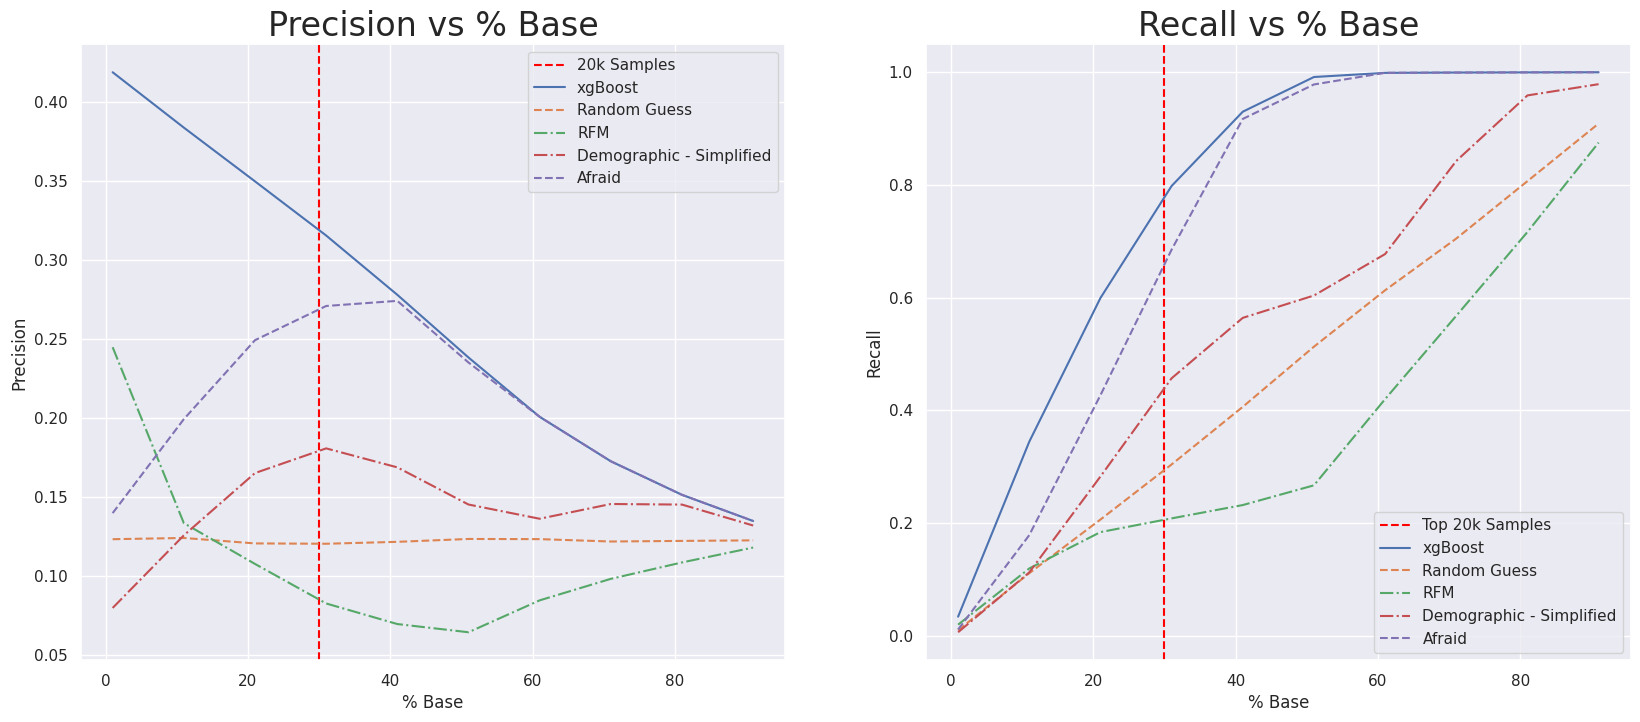

In [125]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,8))
plt.sca(ax1)

plt.axvline(x=20e3/len(y_test)*100, color='red', linestyle='--', label='20k Samples')

percentis_xgboost, precisions_xgboost =  plot_precision_top_k(y_proba=predictions_xg, y_true=y_test.values, 
                                                                label ='xgBoost', chart_points=100)

percentis_random, precisions_random =  plot_precision_top_k(y_proba=predictions_random, y_true=y_test.values, 
                                                                label ='Random Guess', line_style='--', chart_points=100)

percentis_rfm, precisions_rfm       =  plot_precision_top_k(y_proba=df_rfm_test['Proba'].values, y_true=df_rfm_test['Response'].values, 
                                                        label ='RFM', line_style='-.', chart_points=100)

percentis_demo, precisions_demo     =  plot_precision_top_k(y_proba=df_demographic_test['Proba'].values, y_true=df_demographic_test['Response'].values, 
                                                          label ='Demographic - Simplified', line_style='-.', chart_points=100)

percentis_afraid, precisions_afraid  =  plot_precision_top_k(y_proba=afraid_test['Proba'].values, y_true=afraid_test['Response'].values, 
                                                             label ='Afraid', line_style='--', chart_points=100)




plt.sca(ax2)
plt.axvline(x=(20e3/len(X_test))*100, color='red', linestyle='--', label='Top 20k Samples')
percentis_xgboost, recalls_xgboost =     plot_recall_top_k(y_proba=predictions_xg, y_true=y_test.values, label ='xgBoost')
percentis_random, recalls_random = plot_recall_top_k(y_proba=predictions_random, y_true=y_test.values, 
                                                     label ='Random Guess', line_style='--')

percentis_rfm, recalls_rfm       = plot_recall_top_k(y_proba=df_rfm_test['Proba'].values, y_true=df_rfm_test['Response'].values,
                                                     label ='RFM', line_style='-.')

percentis_demo, recalls_demo     = plot_recall_top_k(y_proba=df_demographic_test['Proba'].values, y_true=df_demographic_test['Response'].values,
                                                     label ='Demographic - Simplified', line_style='-.')

percentis_afraid, recalls_afraid  = plot_recall_top_k(y_proba=afraid_test['Proba'].values, y_true=afraid_test['Response'].values,
                                                     label ='Afraid', line_style='--')


**Cruva de lift**

In [123]:
len(percentis_xgboost)

10

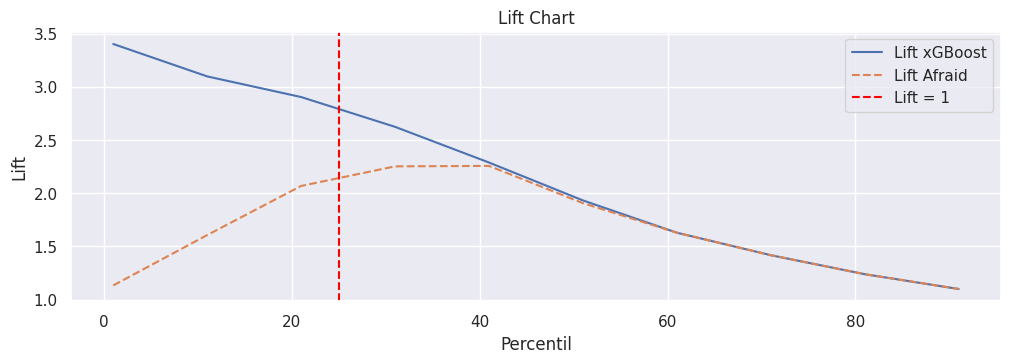

In [126]:
lift_xgboost = [precisions_xgboost[x]/precisions_random[x] for x in range(len(precisions_xgboost))]
lift_afraid = [precisions_afraid[x]/precisions_random[x] for x in range(len(precisions_afraid))]

plt.figure(figsize=(12,3.5))
plt.plot(percentis_xgboost, lift_xgboost, label='Lift xGBoost')
plt.plot(percentis_afraid, lift_afraid, label='Lift Afraid', linestyle='--')
plt.axvline(x=24.98, color='red', linestyle='--', label='Lift = 1')
plt.xlabel('Percentil')
plt.ylabel('Lift')
plt.title('Lift Chart')
plt.legend()
plt.show()

In [127]:
customers_to_reach_xgboost = get_customers_contacted_up_to_revenue(up_to = 1e6,
                                      y_proba=best_xGboost.predict_proba(X_test)[:,1],
                                      y_test=y_test.values,
                                      revenue_per_customer=df_3.Annual_Premium_br.median())


customers_to_reach_afraid = get_customers_contacted_up_to_revenue(up_to = 1e6,
                                      y_proba=afraid_test['Proba'].values,
                                      y_test=afraid_test['Response'].values,
                                      revenue_per_customer=df_3.Annual_Premium_br.median())


customers_to_reach_rfm = get_customers_contacted_up_to_revenue(up_to = 1e6,
                                      y_proba=df_rfm_test['Proba'].values,
                                      y_test=df_rfm_test['Response'].values,
                                      revenue_per_customer=df_3.Annual_Premium_br.median())

print(f'Customers to reach R$ 1M with XGBoost: {customers_to_reach_xgboost}')
print(f'Customers to reach R$ 1M with RFM: {customers_to_reach_rfm}')
print(f'Customers to reach R$ 1M with Afraid: {customers_to_reach_afraid}')



Customers to reach R$ 1M with XGBoost: 911
Customers to reach R$ 1M with RFM: 4944
Customers to reach R$ 1M with Afraid: 2637


#### 5.6 - Conclusion

The best approach to maximize the crosseling is the **xGboost** model, which **achieved 31% of precision** in the top 20k customers vs **26% of the afraid**. 


This means that **for each 100 customers contacted**, the **xGboost model would be able to identify 31 potencial buyers**, while the **afraid would to be able to identify 26 potential buyers.**  


One other reason for that choice, is that xGboost, can **achieve leverage revenue more quickly**, for example to **achieve R$ 1M**, the **xGboost needs to contact 1243 customers**, while the **rfm and afraid business models**, would need to **contact 3602 and 1846 customers respectively**.